In [4]:
import pandas as pd
import numpy as np
from fredapi import Fred # For FRED data
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA
from hmmlearn import hmm
import matplotlib.pyplot as plt
import seaborn as sns
import matplotlib.font_manager as fm # For font management

# --- 로컬 macOS 환경을 위한 폰트 설정 시작 ---
# macOS에서 'AppleGothic' 폰트 사용
# 만약 'AppleGothic' 폰트를 찾을 수 없다는 오류가 계속 발생하면:
# 1. 터미널에서 `python -c "import matplotlib; print(matplotlib.get_cachedir())"` 실행
# 2. 출력된 경로로 이동하여 `.matplotlib` 디렉토리 안에 있는 폰트 캐시 파일(예: `fontlist-xxxx.json`)을 삭제
# 3. 이 스크립트를 다시 실행
# 그래도 안되면 'Apple SD Gothic Neo' 또는 'NanumGothic' 등 다른 시스템 한글 폰트를 시도해보세요.

# Matplotlib 폰트 캐시 지우고 다시 빌드 (가장 중요!)
try:
    fm._rebuild()
except Exception as e:
    print(f"Matplotlib 폰트 캐시 재빌드 중 오류 발생: {e}. 계속 진행합니다.")

# 폰트 설정 (AppleGothic으로 설정)
plt.rcParams['font.family'] = 'AppleGothic'
plt.rcParams['axes.unicode_minus'] = False # 마이너스 기호 깨짐 방지

print("Matplotlib 폰트 설정 완료: 'AppleGothic'")
# --- 폰트 설정 끝 ---


Matplotlib 폰트 캐시 재빌드 중 오류 발생: module 'matplotlib.font_manager' has no attribute '_rebuild'. 계속 진행합니다.
Matplotlib 폰트 설정 완료: 'AppleGothic'


In [2]:
def download_fred_data(api_key, tickers, start_date, end_date):
    """
    FRED API를 사용하여 미국 국채 금리 데이터를 다운로드하고 전처리합니다.
    논문과 동일하게 금리 일일 변화율을 반환합니다.
    """
    if not api_key:
        print("경고: FRED API 키가 설정되지 않았습니다. 데이터를 다운로드할 수 없습니다.")
        print("FRED 웹사이트(fred.stlouisfed.org/docs/api/api_key.html)에서 API 키를 발급받아 FRED_API_KEY 변수에 입력해주세요.")
        return None, None

    fred = Fred(api_key=api_key)
    
    print(f"FRED에서 미국 국채 금리 데이터 다운로드 중: {tickers} ({start_date} ~ {end_date})")
    
    yield_data = pd.DataFrame()
    for ticker in tickers:
        try:
            data = fred.get_series(ticker, observation_start=start_date, observation_end=end_date)
            yield_data[ticker] = data
        except Exception as e:
            print(f"오류: {ticker} 데이터 다운로드 실패: {e}")
            return None, None

    # 데이터 전처리
    # 결측값(NaN)은 앞의 값으로 채우기 (논문에서 daily changes를 사용했으므로 필요)
    yield_data = yield_data.ffill()
    yield_data = yield_data.dropna()

    if yield_data.empty:
        print("경고: 다운로드된 유효한 금리 데이터가 없습니다.")
        return None, None

    # 일일 변화율 계산 (논문에서 금리 일일 변화율을 PCA에 사용)
    daily_changes = yield_data.diff().dropna()

    print(f"다운로드 및 전처리 완료. 데이터셋 크기: {daily_changes.shape}")
    print("일일 변화율 데이터 미리보기:")
    print(daily_changes.head())

    return daily_changes, tickers # tickers를 labels_list로 사용

def perform_pca_and_rolling_eigenvalues(daily_changes_df, labels):
    """
    일일 변화율 데이터에 PCA를 수행하고, 롤링 고유값 시계열을 계산합니다.
    논문과 동일하게 PC1, PC2, PC3의 고유값을 반환합니다.
    """
    # 데이터 스케일링: PCA는 스케일에 민감하므로 데이터를 표준화합니다.
    scaler = StandardScaler()
    scaled_data = scaler.fit_transform(daily_changes_df)
    scaled_data_df = pd.DataFrame(scaled_data, index=daily_changes_df.index, columns=daily_changes_df.columns)

    # 전체 기간 PCA (로딩 시각화용)
    overall_pca = PCA()
    overall_pca.fit(scaled_data)

    # 설명된 분산 비율 출력
    explained_variance_ratio = overall_pca.explained_variance_ratio_
    print(f"\nPCA 결과 - 설명된 분산 비율 (누적):\n{[f'{p*100:.2f}%' for p in np.cumsum(explained_variance_ratio)]}")

    # 주성분 가중치 (고유벡터) 시각화
    plt.figure(figsize=(10, 6))
    x_labels = labels # FRED 티커 이름을 x축 레이블로 사용

    # Ensure there are enough components to plot
    if len(overall_pca.components_) >= 1:
        plt.bar(x_labels, overall_pca.components_[0], label='PC1 (Level)')
    if len(overall_pca.components_) >= 2:
        plt.bar(x_labels, overall_pca.components_[1], label='PC2 (Slope)')
    if len(overall_pca.components_) >= 3:
        plt.bar(x_labels, overall_pca.components_[2], label='PC3 (Curvature)')
    
    plt.title('주성분 로딩 (전체 기간 PCA)')
    plt.xlabel('만기 (FRED 티커)')
    plt.ylabel('로딩')
    plt.legend()
    plt.grid(True)
    plt.tight_layout()
    plt.show()

    # 롤링 PCA 분산 시계열 계산 (PC1, PC2, PC3 모두 사용)
    # 논문과 같이 3개월(60거래일) 롤링 윈도우 사용
    rolling_window = 60
    rolling_eigenvalues = []

    if len(scaled_data_df) < rolling_window:
        print(f"경고: 데이터 길이가 롤링 윈도우({rolling_window}일)보다 짧습니다. 롤링 PCA 고유값을 계산할 수 없습니다.")
        return daily_changes_df, pd.DataFrame(), overall_pca

    for i in range(len(scaled_data_df) - rolling_window + 1):
        window_data = scaled_data_df.iloc[i : i + rolling_window]
        
        # PCA를 다시 생성하여 각 윈도우에 피팅
        pca_window = PCA(n_components=3) # PC1, PC2, PC3 고유값 모두 필요
        pca_window.fit(window_data)
        
        # 첫 번째, 두 번째, 세 번째 주성분의 분산(eigenvalue) 저장
        rolling_eigenvalues.append(pca_window.explained_variance_)

    # pandas DataFrame으로 변환하여 시각화를 위한 인덱스 맞추기
    rolling_eigenvalues_df = pd.DataFrame(
        rolling_eigenvalues,
        columns=['PC1_Eigenvalue', 'PC2_Eigenvalue', 'PC3_Eigenvalue'],
        index=daily_changes_df.index[rolling_window-1:]
    )
    rolling_eigenvalues_df = rolling_eigenvalues_df.dropna() # 혹시 모를 NaN 제거

    print("\n롤링 PCA 계산 완료 (3개 주성분).")
    print("롤링 분산 시계열 데이터 크기:", rolling_eigenvalues_df.shape)
    print("롤링 분산 미리보기:")
    print(rolling_eigenvalues_df.head())

    return daily_changes_df, rolling_eigenvalues_df, overall_pca


def fit_hmm_and_identify_regimes(eigenvalues_df, n_components=2, covariance_type="full"):
    """
    롤링 PCA 고유값 데이터프레임에 Hidden Markov Model을 피팅하고 레짐을 식별합니다.
    """
    eigenvalues_df = eigenvalues_df.dropna()
    if eigenvalues_df.empty:
        print("경고: HMM을 피팅할 충분한 고유값 데이터가 없습니다.")
        return None, pd.Series([]), None, None

    # HMM 모델에 사용할 데이터를 준비 (PC1, PC2, PC3 고유값 모두 사용)
    X_hmm = eigenvalues_df.values

    # HMM 모델 생성 및 학습
    # n_iter: 모델 수렴을 위한 최대 반복 횟수
    # covariance_type: 각 상태의 방출 확률 분포에 대한 공분산 행렬 타입 ("full"은 주성분 간 상관관계 고려)
    model = hmm.GaussianHMM(n_components=n_components, covariance_type=covariance_type, n_iter=500, random_state=42)
    
    # 모델 피팅 시 데이터 부족으로 인한 오류 방지
    if X_hmm.shape[0] < n_components:
        print(f"경고: HMM 피팅에 필요한 데이터 포인트({n_components}개)보다 적습니다. 현재: {X_hmm.shape[0]}개")
        return None, pd.Series([]), None, None
    
    try:
        model.fit(X_hmm)
    except Exception as e:
        print(f"HMM 모델 피팅 중 오류 발생: {e}")
        print("데이터 포인트가 너무 적거나, 특정 상태에 데이터가 몰려 공분산 추정이 어려운 경우 발생할 수 있습니다.")
        return None, pd.Series([]), None, None

    # 은닉 상태 예측
    hidden_states = model.predict(X_hmm)

    # HMM 결과 해석을 위한 상태 식별
    # 여러 주성분을 사용하므로, 각 상태의 전체 분산(공분산 행렬의 흔적, trace)을 기준으로 변동성 순서를 정합니다.
    state_traces = [np.trace(model.covars_[i]) for i in range(n_components)]
    
    # 변동성이 낮은 순서대로 상태 인덱스 정렬
    sorted_state_indices = np.argsort(state_traces)
    
    # 레짐 이름 매핑
    regime_name_map = {}
    if n_components == 2:
        regime_name_map[sorted_state_indices[0]] = '저변동성'
        regime_name_map[sorted_state_indices[1]] = '고변동성'
    elif n_components == 3:
        regime_name_map[sorted_state_indices[0]] = '최저변동성'
        regime_name_map[sorted_state_indices[1]] = '중간변동성'
        regime_name_map[sorted_state_indices[2]] = '최고변동성'
    else: # 4개 이상 레짐의 경우
        for i, idx in enumerate(sorted_state_indices):
            regime_name_map[idx] = f'레짐 {i+1} (변동성 순위)'

    regime_labels_mapped = pd.Series(hidden_states, index=eigenvalues_df.index, name='Regime').map(regime_name_map)

    print(f"\nHMM 피팅 완료 ({n_components}개 레짐, {covariance_type} 공분산):")
    for original_idx in sorted_state_indices:
        print(f"{regime_name_map[original_idx]} 레짐 (평균 고유값 합계): {state_traces[original_idx]:.6f}")

    return model, regime_labels_mapped, regime_name_map.get(sorted_state_indices[-1]), regime_name_map.get(sorted_state_indices[0])


def plot_regimes_and_eigenvalues(eigenvalues_df, regime_labels):
    """
    PC1 고유값 시계열과 식별된 레짐을 함께 시각화합니다.
    """
    if eigenvalues_df.empty or regime_labels.empty:
        print("경고: 플로팅할 고유값 또는 레짐 데이터가 없습니다.")
        return

    plt.figure(figsize=(15, 6))
    
    # PC1 고유값만 플로팅 (논문 Figure 8과 유사하게)
    plt.plot(eigenvalues_df.index, eigenvalues_df['PC1_Eigenvalue'], label='PC1 고유값 (분산)', color='blue', alpha=0.7)

    # 레짐 구간 음영 처리
    unique_regimes = regime_labels.unique()
    # 레짐 이름에 따라 색상 매핑을 위한 정렬 (예: '최저변동성', '저변동성', '중간변동성', '고변동성', '최고변동성')
    sorted_regime_names = sorted(unique_regimes, key=lambda x: {'최저변동성':0, '저변동성':1, '중간변동성':2, '고변동성':3, '최고변동성':4}.get(x, 99))
    
    cmap = plt.cm.get_cmap('viridis', len(unique_regimes)) # 여러 레짐에 다른 색상 사용

    for i, regime_name in enumerate(sorted_regime_names):
        regime_periods = regime_labels[regime_labels == regime_name].index
        
        if not regime_periods.empty:
            # 연속된 날짜 블록 찾기
            # DatetimeIndex를 Series로 변환하여 diff() 사용
            diffs = regime_periods.to_series().diff().dt.days
            
            # 시작점: diff가 1이 아니거나 (새로운 블록 시작), 첫 번째 날짜
            starts = regime_periods[diffs != 1]
            if regime_periods.min() not in starts: # 첫 날짜가 시작점에 포함되지 않았다면 추가
                starts = pd.DatetimeIndex([regime_periods.min()]).union(starts)
            
            # 끝점: diff(-1)이 -1이 아니거나 (블록 끝), 마지막 날짜
            ends = regime_periods[regime_periods.to_series().diff(-1).dt.days != -1]
            if regime_periods.max() not in ends: # 마지막 날짜가 끝점에 포함되지 않았다면 추가
                ends = ends.union(pd.DatetimeIndex([regime_periods.max()]))

            # 시작점과 끝점의 길이가 다를 수 있으므로, 최소 길이로 맞춤
            min_len = min(len(starts), len(ends))
            
            for j in range(min_len):
                # axvspan은 Datetime 객체를 직접 받으므로 .iloc나 [] 사용 가능
                plt.axvspan(starts[j], ends[j], color=cmap(i), alpha=0.3, label=regime_name if j == 0 else "")

    plt.title('PC1 고유값 및 식별된 레짐', fontsize=14)
    plt.xlabel('날짜', fontsize=12)
    plt.ylabel('PC1 고유값 (분산)', fontsize=12)
    plt.legend()
    plt.grid(True)
    plt.tight_layout()
    plt.show()

def calculate_portfolio_metrics(daily_changes_df, regime_labels, high_vol_state_name, low_vol_state_name):
    """
    각 레짐별 포트폴리오 통계 (기대 수익률, 표준편차, 공분산)를 계산합니다.
    논문과 유사하게, 여기서는 금리 변화율 데이터를 사용합니다.
    """
    common_index = daily_changes_df.index.intersection(regime_labels.index)
    if common_index.empty:
        print("경고: 금리 변화율 데이터와 레짐 라벨 간 공통 날짜가 없어 포트폴리오 통계를 계산할 수 없습니다.")
        return {}, {}, {}, {}

    aligned_changes = daily_changes_df.loc[common_index]
    aligned_regimes = regime_labels.loc[common_index]

    unique_regime_names = aligned_regimes.unique()
    regime_metrics = {}
    
    # 공분산 계산을 위한 최소 샘플 수 (자산 개수 + 1)
    min_samples_for_cov = daily_changes_df.shape[1] + 1 

    print("\n포트폴리오 통계 (일일 금리 변화율 기준):")

    # 변동성 순서대로 정렬된 레짐 이름 (출력 일관성을 위해)
    sorted_regime_names = sorted(unique_regime_names, key=lambda x: {'최저변동성':0, '저변동성':1, '중간변동성':2, '고변동성':3, '최고변동성':4}.get(x, 99))

    for r_name in sorted_regime_names:
        regime_data = aligned_changes[aligned_regimes == r_name]
        
        if not regime_data.empty:
            if len(regime_data) >= min_samples_for_cov: 
                mean_change = regime_data.mean()
                cov_matrix = regime_data.cov()
                std_dev = np.sqrt(np.diag(cov_matrix))
                
                print(f"\n--- {r_name} 레짐 ---")
                print(f"평균 일일 금리 변화율:\n{mean_change.to_string()}")
                print(f"일일 금리 변화율 표준편차:\n{pd.Series(std_dev, index=daily_changes_df.columns).to_string()}")
                print(f"일일 금리 변화율 공분산 행렬:\n{cov_matrix.to_string()}")
                regime_metrics[r_name] = {'mean_change': mean_change, 'cov_matrix': cov_matrix}
            else:
                print(f"\n--- {r_name} 레짐 ---")
                print(f"경고: {r_name} 레짐의 데이터 포인트가 공분산 계산에 충분하지 않습니다. (최소 {min_samples_for_cov}개 필요) 현재: {len(regime_data)}개")
                regime_metrics[r_name] = {'mean_change': pd.Series(0, index=daily_changes_df.columns), 'cov_matrix': pd.DataFrame(0, index=daily_changes_df.columns, columns=daily_changes_df.columns)}
        else:
            print(f"\n--- {r_name} 레짐 ---")
            print("해당 레짐의 데이터가 충분하지 않습니다.")
            regime_metrics[r_name] = {'mean_change': pd.Series(0, index=daily_changes_df.columns), 'cov_matrix': pd.DataFrame(0, index=daily_changes_df.columns, columns=daily_changes_df.columns)}

    # 논문 Figure 10과 유사한 효율적 투자선 플로팅을 위해 '고변동성'/'저변동성' 레짐의 통계를 반환
    # HMM n_components가 2개일 경우, high_vol_state_name과 low_vol_state_name이 직접 매핑됩니다.
    # n_components가 3개 이상일 경우, 이들은 '최고변동성', '최저변동성' 등으로 매핑될 수 있습니다.
    high_vol_mean_change = regime_metrics.get(high_vol_state_name, {}).get('mean_change', pd.Series(0, index=daily_changes_df.columns))
    high_vol_cov_matrix = regime_metrics.get(high_vol_state_name, {}).get('cov_matrix', pd.DataFrame(0, index=daily_changes_df.columns, columns=daily_changes_df.columns))
    low_vol_mean_change = regime_metrics.get(low_vol_state_name, {}).get('mean_change', pd.Series(0, index=daily_changes_df.columns))
    low_vol_cov_matrix = regime_metrics.get(low_vol_state_name, {}).get('cov_matrix', pd.DataFrame(0, index=daily_changes_df.columns, columns=daily_changes_df.columns))

    return high_vol_mean_change, high_vol_cov_matrix, low_vol_mean_change, low_vol_cov_matrix


def plot_efficient_frontier(mean_changes, cov_matrix, title):
    """
    주어진 평균 금리 변화율과 공분산 행렬을 사용하여 단순화된 효율적 투자선을 플로팅합니다.
    논문 Figure 10과 유사하게, 금리 변화율의 표준편차(위험)와 평균(수익) 관계를 보여줍니다.
    """
    if mean_changes.empty or cov_matrix.empty or cov_matrix.shape[0] == 0:
        print(f"경고: '{title}' 레짐에 대한 효율적 투자선을 플로팅할 유효한 데이터가 없습니다.")
        return

    num_assets = len(mean_changes)
    num_portfolios = 50000 # 시뮬레이션할 포트폴리오 개수

    results = np.zeros((3, num_portfolios))
    
    # 공분산 행렬이 양의 준정부호인지 확인 (sqrt 계산에 필요)
    try:
        np.linalg.cholesky(cov_matrix)
    except np.linalg.LinAlgError:
        print(f"경고: '{title}' 레짐의 공분산 행렬이 특이하거나 양의 준정부호가 아닙니다. 효율적 투자선을 계산할 수 없습니다. 데이터가 너무 적을 수 있습니다.")
        return

    for i in range(num_portfolios):
        weights = np.random.random(num_assets)
        weights /= np.sum(weights) # 가중치 정규화 (합이 1이 되도록)
        
        # 포트폴리오의 평균 금리 변화율 (기대 수익률 개념)
        portfolio_mean_change = np.sum(weights * mean_changes)
        
        # 포트폴리오의 금리 변화율 표준편차 (위험)
        try:
            portfolio_std_dev = np.sqrt(np.dot(weights.T, np.dot(cov_matrix, weights)))
        except np.linalg.LinAlgError:
            print(f"경고: '{title}' 레짐의 포트폴리오 표준편차 계산 중 오류 발생. 효율적 투자선을 계산할 수 없습니다.")
            return

        # 샤프 비율 (여기서는 무위험 금리 변화율을 0으로 가정)
        sharpe_ratio = portfolio_mean_change / portfolio_std_dev if portfolio_std_dev != 0 else 0
        
        results[0, i] = portfolio_std_dev
        results[1, i] = portfolio_mean_change
        results[2, i] = sharpe_ratio

    # 결과를 Pandas DataFrame으로 변환
    results_frame = pd.DataFrame(results.T, columns=['Std Dev', 'Mean Change', 'Sharpe Ratio'])

    # 최대 샤프 비율 포트폴리오와 최소 분산 포트폴리오 찾기
    max_sharpe_portfolio = results_frame.iloc[results_frame['Sharpe Ratio'].idxmax()]
    min_vol_portfolio = results_frame.iloc[results_frame['Std Dev'].idxmin()]

    plt.figure(figsize=(10, 6))
    plt.scatter(results_frame['Std Dev'], results_frame['Mean Change'], c=results_frame['Sharpe Ratio'], cmap='viridis', s=10, alpha=0.3)
    plt.colorbar(label='샤프 비율')
    plt.scatter(max_sharpe_portfolio[0], max_sharpe_portfolio[1], marker='*', color='red', s=500, label='최대 샤프 비율 포트폴리오')
    plt.scatter(min_vol_portfolio[0], min_vol_portfolio[1], marker='o', color='blue', s=200, label='최소 분산 포트폴리오')

    plt.title(f'{title} 레짐 효율적 투자선 (금리 변화율 기준)')
    plt.xlabel('표준편차 (일일 금리 변화율)')
    plt.ylabel('평균 (일일 금리 변화율)')
    plt.legend()
    plt.grid(True)
    plt.tight_layout()
    plt.show()


1. FRED API를 통해 미국 국채 금리 데이터 다운로드 및 전처리 중...
FRED에서 미국 국채 금리 데이터 다운로드 중: ['DGS6MO', 'DGS1', 'DGS2', 'DGS5', 'DGS7', 'DGS10'] (1996-01-01 ~ 2025-07-31)
다운로드 및 전처리 완료. 데이터셋 크기: (7717, 6)
일일 변화율 데이터 미리보기:
            DGS6MO  DGS1  DGS2  DGS5  DGS7  DGS10
1996-01-03   -0.03 -0.01 -0.01 -0.03 -0.02  -0.02
1996-01-04    0.01  0.03  0.00  0.03  0.06   0.07
1996-01-05   -0.01  0.00  0.03  0.03  0.04   0.04
1996-01-08    0.00  0.00  0.00 -0.01 -0.03  -0.01
1996-01-09   -0.02 -0.03 -0.02  0.00  0.02   0.02

2. 주성분 분석 (PCA) 수행 및 롤링 고유값 계산 중...

PCA 결과 - 설명된 분산 비율 (누적):
['78.10%', '93.69%', '97.53%', '99.17%', '99.73%', '100.00%']


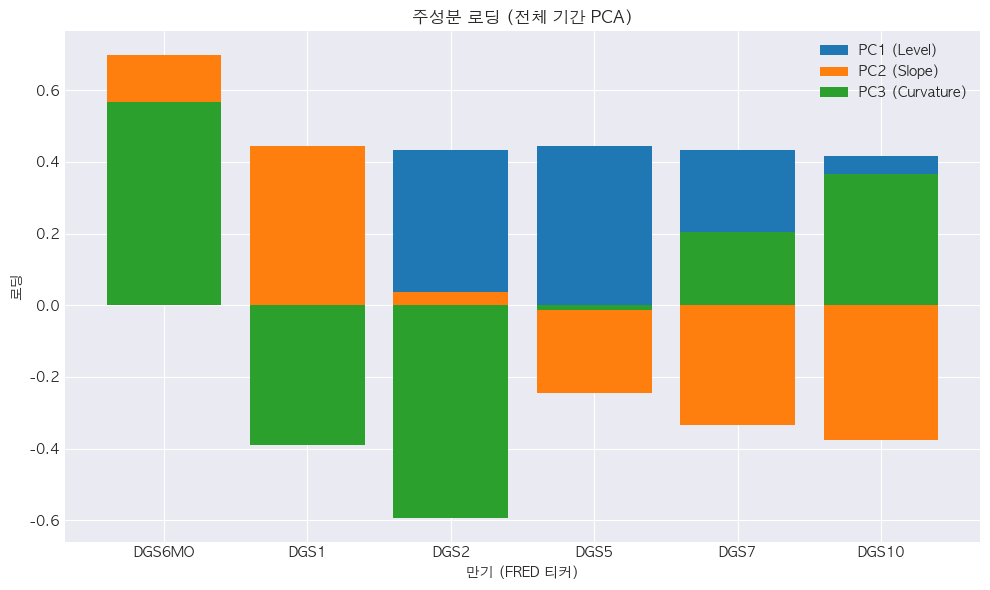


롤링 PCA 계산 완료 (3개 주성분).
롤링 분산 시계열 데이터 크기: (7658, 3)
롤링 분산 미리보기:
            PC1_Eigenvalue  PC2_Eigenvalue  PC3_Eigenvalue
1996-03-26       10.190386        0.496352        0.190115
1996-03-27       10.356488        0.511583        0.190892
1996-03-28       10.434440        0.508289        0.187716
1996-03-29       10.681624        0.506505        0.190520
1996-04-01       10.674648        0.549663        0.195547
PCA 완료.

3. 히든 마르코프 모델 (HMM) 피팅 및 레짐 식별 중...

HMM 피팅 완료 (2개 레짐, full 공분산):
저변동성 레짐 (평균 고유값 합계): 3.462818
고변동성 레짐 (평균 고유값 합계): 46.910037
HMM 피팅 및 레짐 식별 완료.

4. 식별된 레짐 시각화 중...


/var/folders/s9/n_x99kd14qn9k67jr3rn8cf40000gn/T/ipykernel_29956/72525600.py:194: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed two minor releases later. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap(obj)`` instead.
  cmap = plt.cm.get_cmap('viridis', len(unique_regimes)) # 여러 레짐에 다른 색상 사용


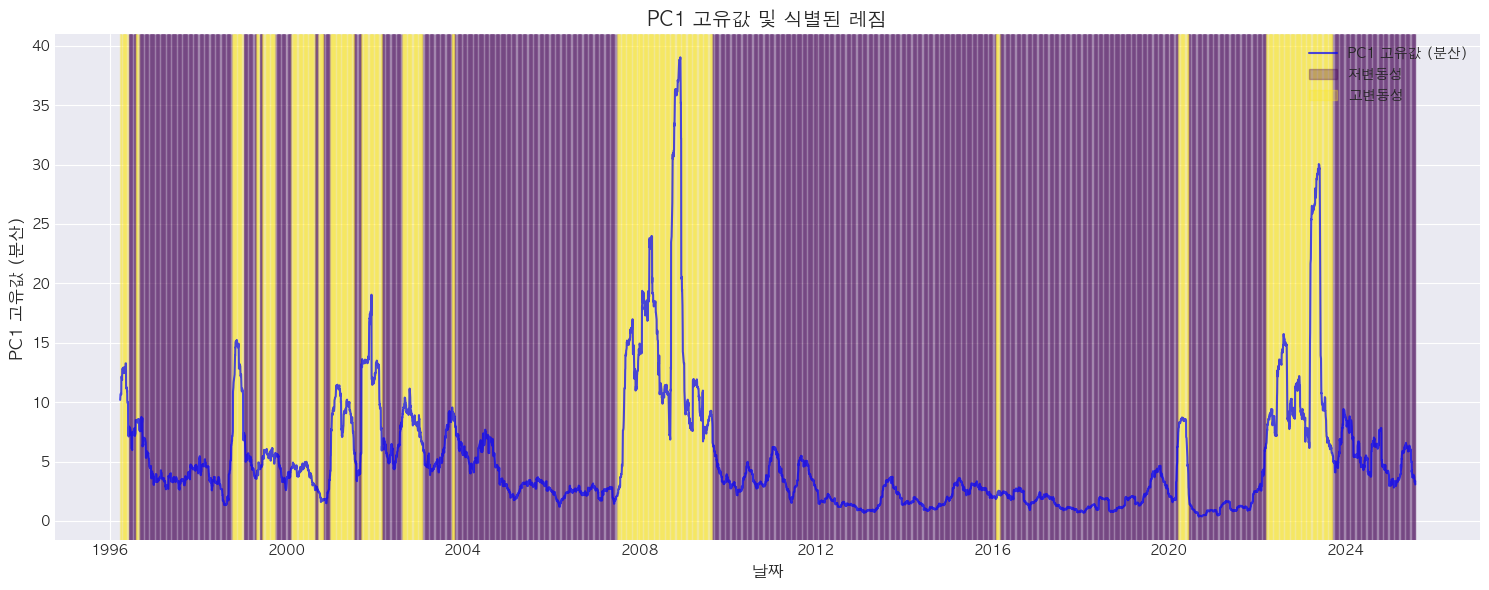

레짐 시각화 완료.

5. 각 레짐별 포트폴리오 통계 계산 중...

포트폴리오 통계 (일일 금리 변화율 기준):

--- 저변동성 레짐 ---
평균 일일 금리 변화율:
DGS6MO    0.000326
DGS1      0.000163
DGS2     -0.000031
DGS5     -0.000414
DGS7     -0.000553
DGS10    -0.000601
일일 금리 변화율 표준편차:
DGS6MO    0.024171
DGS1      0.029606
DGS2      0.042581
DGS5      0.050548
DGS7      0.051877
DGS10     0.050208
일일 금리 변화율 공분산 행렬:
          DGS6MO      DGS1      DGS2      DGS5      DGS7     DGS10
DGS6MO  0.000584  0.000535  0.000614  0.000606  0.000567  0.000521
DGS1    0.000535  0.000876  0.001042  0.001059  0.001000  0.000909
DGS2    0.000614  0.001042  0.001813  0.001895  0.001814  0.001648
DGS5    0.000606  0.001059  0.001895  0.002555  0.002544  0.002381
DGS7    0.000567  0.001000  0.001814  0.002544  0.002691  0.002537
DGS10   0.000521  0.000909  0.001648  0.002381  0.002537  0.002521

--- 고변동성 레짐 ---
평균 일일 금리 변화율:
DGS6MO   -0.001499
DGS1     -0.001215
DGS2     -0.000856
DGS5      0.000202
DGS7      0.000632
DGS10     0.000877
일일 금리 변화율 표준편차:
DGS6MO    0.0

/var/folders/s9/n_x99kd14qn9k67jr3rn8cf40000gn/T/ipykernel_29956/72525600.py:339: FutureWarning: Series.__getitem__ treating keys as positions is deprecated. In a future version, integer keys will always be treated as labels (consistent with DataFrame behavior). To access a value by position, use `ser.iloc[pos]`
  plt.scatter(max_sharpe_portfolio[0], max_sharpe_portfolio[1], marker='*', color='red', s=500, label='최대 샤프 비율 포트폴리오')
/var/folders/s9/n_x99kd14qn9k67jr3rn8cf40000gn/T/ipykernel_29956/72525600.py:340: FutureWarning: Series.__getitem__ treating keys as positions is deprecated. In a future version, integer keys will always be treated as labels (consistent with DataFrame behavior). To access a value by position, use `ser.iloc[pos]`
  plt.scatter(min_vol_portfolio[0], min_vol_portfolio[1], marker='o', color='blue', s=200, label='최소 분산 포트폴리오')


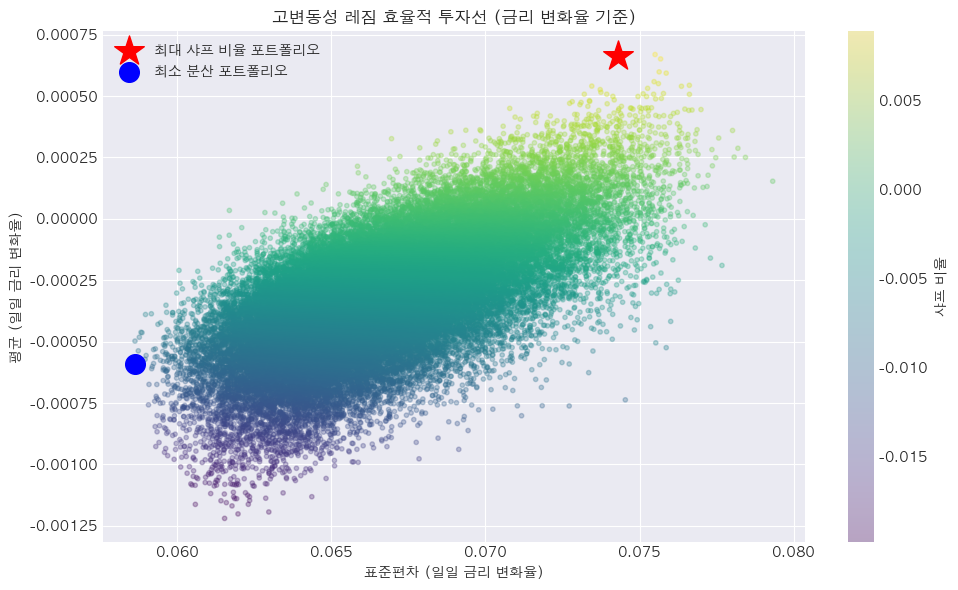

/var/folders/s9/n_x99kd14qn9k67jr3rn8cf40000gn/T/ipykernel_29956/72525600.py:339: FutureWarning: Series.__getitem__ treating keys as positions is deprecated. In a future version, integer keys will always be treated as labels (consistent with DataFrame behavior). To access a value by position, use `ser.iloc[pos]`
  plt.scatter(max_sharpe_portfolio[0], max_sharpe_portfolio[1], marker='*', color='red', s=500, label='최대 샤프 비율 포트폴리오')
/var/folders/s9/n_x99kd14qn9k67jr3rn8cf40000gn/T/ipykernel_29956/72525600.py:340: FutureWarning: Series.__getitem__ treating keys as positions is deprecated. In a future version, integer keys will always be treated as labels (consistent with DataFrame behavior). To access a value by position, use `ser.iloc[pos]`
  plt.scatter(min_vol_portfolio[0], min_vol_portfolio[1], marker='o', color='blue', s=200, label='최소 분산 포트폴리오')


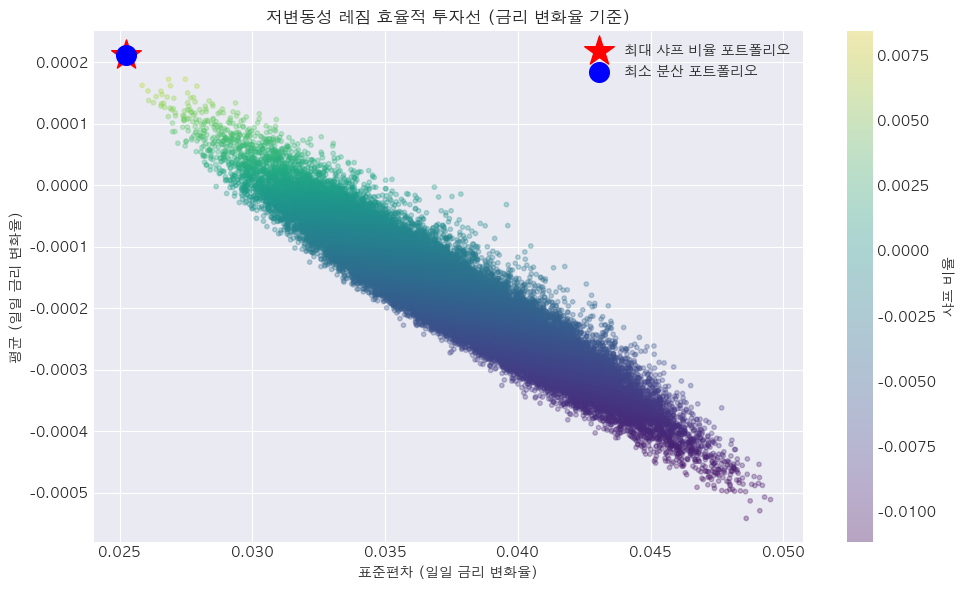

효율적 투자선 플로팅 완료.

논문 기반 레짐 포트폴리오 최적화 개념 구현이 완료되었습니다.


In [5]:
# --- 메인 실행 흐름 ---
if __name__ == "__main__":
    # --- FRED API 키 설정 ---
    # FRED 웹사이트(fred.stlouisfed.org/docs/api/api_key.html)에서 API 키를 발급받아 아래에 입력해주세요.
    # 예: FRED_API_KEY = "YOUR_FRED_API_KEY_HERE"
    FRED_API_KEY = "46a60a0c8efc71d104b079205137c53e" # 여기에 발급받은 FRED API 키를 입력하세요.

    # 논문에서 언급된 만기별 FRED 티커 정의
    # DGS6MO: 6-Month Treasury Constant Maturity Rate
    # DGS1: 1-Year Treasury Constant Maturity Rate
    # DGS2: 2-Year Treasury Constant Maturity Rate
    # DGS5: 5-Year Treasury Constant Maturity Rate
    # DGS7: 7-Year Treasury Constant Maturity Rate
    # DGS10: 10-Year Treasury Constant Maturity Rate
    fred_tickers = ['DGS6MO', 'DGS1', 'DGS2', 'DGS5', 'DGS7', 'DGS10']
    
    # 논문에서 사용된 기간 (1996-01-01부터 2025-07-31)
    start_date = '1996-01-01'
    end_date = '2025-07-31'

    print("1. FRED API를 통해 미국 국채 금리 데이터 다운로드 및 전처리 중...")
    daily_changes_df, labels_list = download_fred_data(FRED_API_KEY, fred_tickers, start_date, end_date)
    
    if daily_changes_df is None or daily_changes_df.empty:
        print("데이터 로드 또는 전처리 실패. 스크립트를 종료합니다.")
        exit()

    print("\n2. 주성분 분석 (PCA) 수행 및 롤링 고유값 계산 중...")
    # daily_changes_df: 금리 일일 변화율 데이터
    # rolling_eigenvalues_df: PC1, PC2, PC3의 롤링 고유값 시계열
    # overall_pca_model: 전체 기간 PCA 모델 객체 (로딩 플로팅용)
    daily_changes_df, rolling_eigenvalues_df, overall_pca_model = perform_pca_and_rolling_eigenvalues(daily_changes_df, labels_list)
    print("PCA 완료.")

    print("\n3. 히든 마르코프 모델 (HMM) 피팅 및 레짐 식별 중...")
    # HMM은 롤링 고유값 데이터가 있어야 피팅 가능
    if not rolling_eigenvalues_df.empty:
        # 논문과 유사하게 PC1, PC2, PC3 고유값 모두 입력으로 사용, covariance_type="full"
        # n_components를 3개로 시도해보고 싶다면 아래 주석을 풀고, high_vol_state_name_for_plot/low_vol_state_name_for_plot도 적절히 변경하세요.
        model, regime_labels, high_vol_state_name_for_plot, low_vol_state_name_for_plot = fit_hmm_and_identify_regimes(
            rolling_eigenvalues_df, n_components=2, covariance_type="full"
        )
        
        # n_components=3으로 시도하는 예시:
        # model, regime_labels, _, _ = fit_hmm_and_identify_regimes(
        #     rolling_eigenvalues_df, n_components=3, covariance_type="full"
        # )
        # # 3개 레짐일 경우, 가장 변동성이 높은 레짐과 가장 낮은 레짐을 명시적으로 지정
        # high_vol_state_name_for_plot = '최고변동성'
        # low_vol_state_name_for_plot = '최저변동성'


        if model is None: # HMM 피팅 실패 (예: 데이터 부족)
            print("HMM 피팅 실패. 다음 단계로 진행할 수 없습니다.")
        else:
            print("HMM 피팅 및 레짐 식별 완료.")

            print("\n4. 식별된 레짐 시각화 중...")
            plot_regimes_and_eigenvalues(rolling_eigenvalues_df, regime_labels)
            print("레짐 시각화 완료.")

            print("\n5. 각 레짐별 포트폴리오 통계 계산 중...")
            # calculate_portfolio_metrics 함수는 내부적으로 high_vol_state_name_for_plot과 low_vol_state_name_for_plot을 사용하여 통계를 반환합니다.
            high_vol_mean_change, high_vol_cov_matrix, low_vol_mean_change, low_vol_cov_matrix = \
                calculate_portfolio_metrics(daily_changes_df, regime_labels, high_vol_state_name_for_plot, low_vol_state_name_for_plot)
            print("포트폴리오 통계 계산 완료.")

            print("\n6. 각 레짐별 효율적 투자선 플로팅 중...")
            # 논문 Figure 10과 유사하게, 금리 변화율의 표준편차(위험)와 평균(수익) 관계를 보여줍니다.
            plot_efficient_frontier(high_vol_mean_change, high_vol_cov_matrix, high_vol_state_name_for_plot)
            plot_efficient_frontier(low_vol_mean_change, low_vol_cov_matrix, low_vol_state_name_for_plot)
            print("효율적 투자선 플로팅 완료.")
    else:
        print("롤링 고유값 데이터가 충분하지 않아 HMM 및 이후 분석을 수행할 수 없습니다.")

    print("\n논문 기반 레짐 포트폴리오 최적화 개념 구현이 완료되었습니다.")


In [6]:
import pandas as pd
import numpy as np
from fredapi import Fred # For FRED data
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA
from hmmlearn import hmm
import matplotlib.pyplot as plt
import seaborn as sns
import matplotlib.font_manager as fm # For font management

# --- 로컬 macOS 환경을 위한 폰트 설정 시작 ---
# macOS에서 'AppleGothic' 폰트 사용
# 만약 'AppleGothic' 폰트를 찾을 수 없다는 오류가 계속 발생하면:
# 1. 터미널에서 `python -c "import matplotlib; print(matplotlib.get_cachedir())"` 실행
# 2. 출력된 경로로 이동하여 `.matplotlib` 디렉토리 안에 있는 폰트 캐시 파일(예: `fontlist-xxxx.json`)을 삭제
# 3. 이 스크립트를 다시 실행
# 그래도 안되면 'Apple SD Gothic Neo' 또는 'NanumGothic' 등 다른 시스템 한글 폰트를 시도해보세요.

# Matplotlib 폰트 캐시 지우고 다시 빌드 (가장 중요!)
try:
    fm._rebuild()
except Exception as e:
    print(f"Matplotlib 폰트 캐시 재빌드 중 오류 발생: {e}. 계속 진행합니다.")

# 폰트 설정 (AppleGothic으로 설정)
plt.rcParams['font.family'] = 'AppleGothic'
plt.rcParams['axes.unicode_minus'] = False # 마이너스 기호 깨짐 방지

print("Matplotlib 폰트 설정 완료: 'AppleGothic'")


Matplotlib 폰트 캐시 재빌드 중 오류 발생: module 'matplotlib.font_manager' has no attribute '_rebuild'. 계속 진행합니다.
Matplotlib 폰트 설정 완료: 'AppleGothic'


In [7]:

def download_fred_data(api_key, tickers, start_date, end_date):
    """
    FRED API를 사용하여 미국 국채 금리 데이터를 다운로드하고 전처리합니다.
    논문과 동일하게 금리 일일 변화율을 반환합니다.
    """
    if not api_key:
        print("경고: FRED API 키가 설정되지 않았습니다. 데이터를 다운로드할 수 없습니다.")
        print("FRED 웹사이트(fred.stlouisfed.org/docs/api/api_key.html)에서 API 키를 발급받아 FRED_API_KEY 변수에 입력해주세요.")
        return None, None

    fred = Fred(api_key=api_key)
    
    print(f"FRED에서 미국 국채 금리 데이터 다운로드 중: {tickers} ({start_date} ~ {end_date})")
    
    yield_data = pd.DataFrame()
    for ticker in tickers:
        try:
            data = fred.get_series(ticker, observation_start=start_date, observation_end=end_date)
            yield_data[ticker] = data
        except Exception as e:
            print(f"오류: {ticker} 데이터 다운로드 실패: {e}")
            return None, None

    # 데이터 전처리
    # 결측값(NaN)은 앞의 값으로 채우기 (논문에서 daily changes를 사용했으므로 필요)
    yield_data = yield_data.ffill()
    yield_data = yield_data.dropna()

    if yield_data.empty:
        print("경고: 다운로드된 유효한 금리 데이터가 없습니다.")
        return None, None

    # 일일 변화율 계산 (논문에서 금리 일일 변화율을 PCA에 사용)
    daily_changes = yield_data.diff().dropna()

    print(f"다운로드 및 전처리 완료. 데이터셋 크기: {daily_changes.shape}")
    print("일일 변화율 데이터 미리보기:")
    print(daily_changes.head())

    return daily_changes, tickers # tickers를 labels_list로 사용

def perform_pca_and_rolling_eigenvalues(daily_changes_df, labels):
    """
    일일 변화율 데이터에 PCA를 수행하고, 롤링 고유값 시계열을 계산합니다.
    논문과 동일하게 PC1, PC2, PC3의 고유값을 반환합니다.
    """
    # 데이터 스케일링: PCA는 스케일에 민감하므로 데이터를 표준화합니다.
    scaler = StandardScaler()
    scaled_data = scaler.fit_transform(daily_changes_df)
    scaled_data_df = pd.DataFrame(scaled_data, index=daily_changes_df.index, columns=daily_changes_df.columns)

    # 전체 기간 PCA (로딩 시각화용)
    overall_pca = PCA()
    overall_pca.fit(scaled_data)

    # 설명된 분산 비율 출력
    explained_variance_ratio = overall_pca.explained_variance_ratio_
    print(f"\nPCA 결과 - 설명된 분산 비율 (누적):\n{[f'{p*100:.2f}%' for p in np.cumsum(explained_variance_ratio)]}")

    # 주성분 가중치 (고유벡터) 시각화
    plt.figure(figsize=(10, 6))
    x_labels = labels # FRED 티커 이름을 x축 레이블로 사용

    # Ensure there are enough components to plot
    if len(overall_pca.components_) >= 1:
        plt.bar(x_labels, overall_pca.components_[0], label='PC1 (Level)')
    if len(overall_pca.components_) >= 2:
        plt.bar(x_labels, overall_pca.components_[1], label='PC2 (Slope)')
    if len(overall_pca.components_) >= 3:
        plt.bar(x_labels, overall_pca.components_[2], label='PC3 (Curvature)')
    
    plt.title('주성분 로딩 (전체 기간 PCA)')
    plt.xlabel('만기 (FRED 티커)')
    plt.ylabel('로딩')
    plt.legend()
    plt.grid(True)
    plt.tight_layout()
    plt.show()

    # 롤링 PCA 분산 시계열 계산 (PC1, PC2, PC3 모두 사용)
    # 논문과 같이 3개월(60거래일) 롤링 윈도우 사용
    rolling_window = 60
    rolling_eigenvalues = []

    if len(scaled_data_df) < rolling_window:
        print(f"경고: 데이터 길이가 롤링 윈도우({rolling_window}일)보다 짧습니다. 롤링 PCA 고유값을 계산할 수 없습니다.")
        return daily_changes_df, pd.DataFrame(), overall_pca

    for i in range(len(scaled_data_df) - rolling_window + 1):
        window_data = scaled_data_df.iloc[i : i + rolling_window]
        
        # PCA를 다시 생성하여 각 윈도우에 피팅
        pca_window = PCA(n_components=3) # PC1, PC2, PC3 고유값 모두 필요
        pca_window.fit(window_data)
        
        # 첫 번째, 두 번째, 세 번째 주성분의 분산(eigenvalue) 저장
        rolling_eigenvalues.append(pca_window.explained_variance_)

    # pandas DataFrame으로 변환하여 시각화를 위한 인덱스 맞추기
    rolling_eigenvalues_df = pd.DataFrame(
        rolling_eigenvalues,
        columns=['PC1_Eigenvalue', 'PC2_Eigenvalue', 'PC3_Eigenvalue'],
        index=daily_changes_df.index[rolling_window-1:]
    )
    rolling_eigenvalues_df = rolling_eigenvalues_df.dropna() # 혹시 모를 NaN 제거

    print("\n롤링 PCA 계산 완료 (3개 주성분).")
    print("롤링 분산 시계열 데이터 크기:", rolling_eigenvalues_df.shape)
    print("롤링 분산 미리보기:")
    print(rolling_eigenvalues_df.head())

    return daily_changes_df, rolling_eigenvalues_df, overall_pca


def fit_hmm_and_identify_regimes(eigenvalues_df, n_components=2, covariance_type="full"):
    """
    롤링 PCA 고유값 데이터프레임에 Hidden Markov Model을 피팅하고 레짐을 식별합니다.
    """
    eigenvalues_df = eigenvalues_df.dropna()
    if eigenvalues_df.empty:
        print("경고: HMM을 피팅할 충분한 고유값 데이터가 없습니다.")
        return None, pd.Series([]), None, None

    # HMM 모델에 사용할 데이터를 준비 (PC1, PC2, PC3 고유값 모두 사용)
    X_hmm = eigenvalues_df.values

    # HMM 모델 생성 및 학습
    # n_iter: 모델 수렴을 위한 최대 반복 횟수
    # covariance_type: 각 상태의 방출 확률 분포에 대한 공분산 행렬 타입 ("full"은 주성분 간 상관관계 고려)
    model = hmm.GaussianHMM(n_components=n_components, covariance_type=covariance_type, n_iter=500, random_state=42)
    
    # 모델 피팅 시 데이터 부족으로 인한 오류 방지
    if X_hmm.shape[0] < n_components:
        print(f"경고: HMM 피팅에 필요한 데이터 포인트({n_components}개)보다 적습니다. 현재: {X_hmm.shape[0]}개")
        return None, pd.Series([]), None, None
    
    try:
        model.fit(X_hmm)
    except Exception as e:
        print(f"HMM 모델 피팅 중 오류 발생: {e}")
        print("데이터 포인트가 너무 적거나, 특정 상태에 데이터가 몰려 공분산 추정이 어려운 경우 발생할 수 있습니다.")
        return None, pd.Series([]), None, None

    # 은닉 상태 예측
    hidden_states = model.predict(X_hmm)

    # HMM 결과 해석을 위한 상태 식별
    # 여러 주성분을 사용하므로, 각 상태의 전체 분산(공분산 행렬의 흔적, trace)을 기준으로 변동성 순서를 정합니다.
    state_traces = [np.trace(model.covars_[i]) for i in range(n_components)]
    
    # 변동성이 낮은 순서대로 상태 인덱스 정렬
    sorted_state_indices = np.argsort(state_traces)
    
    # 레짐 이름 매핑
    regime_name_map = {}
    if n_components == 2:
        regime_name_map[sorted_state_indices[0]] = '저변동성'
        regime_name_map[sorted_state_indices[1]] = '고변동성'
    elif n_components == 3:
        regime_name_map[sorted_state_indices[0]] = '최저변동성'
        regime_name_map[sorted_state_indices[1]] = '중간변동성'
        regime_name_map[sorted_state_indices[2]] = '최고변동성'
    else: # 4개 이상 레짐의 경우
        for i, idx in enumerate(sorted_state_indices):
            regime_name_map[idx] = f'레짐 {i+1} (변동성 순위)'

    regime_labels_mapped = pd.Series(hidden_states, index=eigenvalues_df.index, name='Regime').map(regime_name_map)

    print(f"\nHMM 피팅 완료 ({n_components}개 레짐, {covariance_type} 공분산):")
    for original_idx in sorted_state_indices:
        print(f"{regime_name_map[original_idx]} 레짐 (평균 고유값 합계): {state_traces[original_idx]:.6f}")

    return model, regime_labels_mapped, regime_name_map.get(sorted_state_indices[-1]), regime_name_map.get(sorted_state_indices[0])


def plot_regimes_and_eigenvalues(eigenvalues_df, regime_labels):
    """
    PC1 고유값 시계열과 식별된 레짐을 함께 시각화합니다.
    """
    if eigenvalues_df.empty or regime_labels.empty:
        print("경고: 플로팅할 고유값 또는 레짐 데이터가 없습니다.")
        return

    plt.figure(figsize=(15, 6))
    
    # PC1 고유값만 플로팅 (논문 Figure 8과 유사하게)
    plt.plot(eigenvalues_df.index, eigenvalues_df['PC1_Eigenvalue'], label='PC1 고유값 (분산)', color='blue', alpha=0.7)

    # 레짐 구간 음영 처리
    unique_regimes = regime_labels.unique()
    # 레짐 이름에 따라 색상 매핑을 위한 정렬 (예: '최저변동성', '저변동성', '중간변동성', '고변동성', '최고변동성')
    sorted_regime_names = sorted(unique_regimes, key=lambda x: {'최저변동성':0, '저변동성':1, '중간변동성':2, '고변동성':3, '최고변동성':4}.get(x, 99))
    
    cmap = plt.cm.get_cmap('viridis', len(unique_regimes)) # 여러 레짐에 다른 색상 사용

    for i, regime_name in enumerate(sorted_regime_names):
        regime_periods = regime_labels[regime_labels == regime_name].index
        
        if not regime_periods.empty:
            # 연속된 날짜 블록 찾기
            # DatetimeIndex를 Series로 변환하여 diff() 사용
            diffs = regime_periods.to_series().diff().dt.days
            
            # 시작점: diff가 1이 아니거나 (새로운 블록 시작), 첫 번째 날짜
            starts = regime_periods[diffs != 1]
            if regime_periods.min() not in starts: # 첫 날짜가 시작점에 포함되지 않았다면 추가
                starts = pd.DatetimeIndex([regime_periods.min()]).union(starts)
            
            # 끝점: diff(-1)이 -1이 아니거나 (블록 끝), 마지막 날짜
            ends = regime_periods[regime_periods.to_series().diff(-1).dt.days != -1]
            if regime_periods.max() not in ends: # 마지막 날짜가 끝점에 포함되지 않았다면 추가
                ends = ends.union(pd.DatetimeIndex([regime_periods.max()]))

            # 시작점과 끝점의 길이가 다를 수 있으므로, 최소 길이로 맞춤
            min_len = min(len(starts), len(ends))
            
            for j in range(min_len):
                # axvspan은 Datetime 객체를 직접 받으므로 .iloc나 [] 사용 가능
                plt.axvspan(starts[j], ends[j], color=cmap(i), alpha=0.3, label=regime_name if j == 0 else "")

    plt.title('PC1 고유값 및 식별된 레짐', fontsize=14)
    plt.xlabel('날짜', fontsize=12)
    plt.ylabel('PC1 고유값 (분산)', fontsize=12)
    plt.legend()
    plt.grid(True)
    plt.tight_layout()
    plt.show()

def calculate_portfolio_metrics(daily_changes_df, regime_labels, high_vol_state_name, low_vol_state_name):
    """
    각 레짐별 포트폴리오 통계 (기대 수익률, 표준편차, 공분산)를 계산합니다.
    논문과 유사하게, 여기서는 금리 변화율 데이터를 사용합니다.
    """
    common_index = daily_changes_df.index.intersection(regime_labels.index)
    if common_index.empty:
        print("경고: 금리 변화율 데이터와 레짐 라벨 간 공통 날짜가 없어 포트폴리오 통계를 계산할 수 없습니다.")
        return {}, {}, {}, {}

    aligned_changes = daily_changes_df.loc[common_index]
    aligned_regimes = regime_labels.loc[common_index]

    unique_regime_names = aligned_regimes.unique()
    regime_metrics = {}
    
    # 공분산 계산을 위한 최소 샘플 수 (자산 개수 + 1)
    min_samples_for_cov = daily_changes_df.shape[1] + 1 

    print("\n포트폴리오 통계 (일일 금리 변화율 기준):")

    # 변동성 순서대로 정렬된 레짐 이름 (출력 일관성을 위해)
    sorted_regime_names = sorted(unique_regime_names, key=lambda x: {'최저변동성':0, '저변동성':1, '중간변동성':2, '고변동성':3, '최고변동성':4}.get(x, 99))

    for r_name in sorted_regime_names:
        regime_data = aligned_changes[aligned_regimes == r_name]
        
        if not regime_data.empty:
            if len(regime_data) >= min_samples_for_cov: 
                mean_change = regime_data.mean()
                cov_matrix = regime_data.cov()
                std_dev = np.sqrt(np.diag(cov_matrix))
                
                print(f"\n--- {r_name} 레짐 ---")
                print(f"평균 일일 금리 변화율:\n{mean_change.to_string()}")
                print(f"일일 금리 변화율 표준편차:\n{pd.Series(std_dev, index=daily_changes_df.columns).to_string()}")
                print(f"일일 금리 변화율 공분산 행렬:\n{cov_matrix.to_string()}")
                regime_metrics[r_name] = {'mean_change': mean_change, 'cov_matrix': cov_matrix}
            else:
                print(f"\n--- {r_name} 레짐 ---")
                print(f"경고: {r_name} 레짐의 데이터 포인트가 공분산 계산에 충분하지 않습니다. (최소 {min_samples_for_cov}개 필요) 현재: {len(regime_data)}개")
                regime_metrics[r_name] = {'mean_change': pd.Series(0, index=daily_changes_df.columns), 'cov_matrix': pd.DataFrame(0, index=daily_changes_df.columns, columns=daily_changes_df.columns)}
        else:
            print(f"\n--- {r_name} 레짐 ---")
            print("해당 레짐의 데이터가 충분하지 않습니다.")
            regime_metrics[r_name] = {'mean_change': pd.Series(0, index=daily_changes_df.columns), 'cov_matrix': pd.DataFrame(0, index=daily_changes_df.columns, columns=daily_changes_df.columns)}

    # 논문 Figure 10과 유사한 효율적 투자선 플로팅을 위해 '고변동성'/'저변동성' 레짐의 통계를 반환
    # HMM n_components가 2개일 경우, high_vol_state_name과 low_vol_state_name이 직접 매핑됩니다.
    # n_components가 3개 이상일 경우, 이들은 '최고변동성', '최저변동성' 등으로 매핑될 수 있습니다.
    high_vol_mean_change = regime_metrics.get(high_vol_state_name, {}).get('mean_change', pd.Series(0, index=daily_changes_df.columns))
    high_vol_cov_matrix = regime_metrics.get(high_vol_state_name, {}).get('cov_matrix', pd.DataFrame(0, index=daily_changes_df.columns, columns=daily_changes_df.columns))
    low_vol_mean_change = regime_metrics.get(low_vol_state_name, {}).get('mean_change', pd.Series(0, index=daily_changes_df.columns))
    low_vol_cov_matrix = regime_metrics.get(low_vol_state_name, {}).get('cov_matrix', pd.DataFrame(0, index=daily_changes_df.columns, columns=daily_changes_df.columns))

    return high_vol_mean_change, high_vol_cov_matrix, low_vol_mean_change, low_vol_cov_matrix


def plot_efficient_frontier(mean_changes, cov_matrix, title):
    """
    주어진 평균 금리 변화율과 공분산 행렬을 사용하여 단순화된 효율적 투자선을 플로팅합니다.
    논문 Figure 10과 유사하게, 금리 변화율의 표준편차(위험)와 평균(수익) 관계를 보여줍니다.
    """
    if mean_changes.empty or cov_matrix.empty or cov_matrix.shape[0] == 0:
        print(f"경고: '{title}' 레짐에 대한 효율적 투자선을 플로팅할 유효한 데이터가 없습니다.")
        return

    num_assets = len(mean_changes)
    num_portfolios = 50000 # 시뮬레이션할 포트폴리오 개수

    results = np.zeros((3, num_portfolios))
    
    # 공분산 행렬이 양의 준정부호인지 확인 (sqrt 계산에 필요)
    try:
        np.linalg.cholesky(cov_matrix)
    except np.linalg.LinAlgError:
        print(f"경고: '{title}' 레짐의 공분산 행렬이 특이하거나 양의 준정부호가 아닙니다. 효율적 투자선을 계산할 수 없습니다. 데이터가 너무 적을 수 있습니다.")
        return

    for i in range(num_portfolios):
        weights = np.random.random(num_assets)
        weights /= np.sum(weights) # 가중치 정규화 (합이 1이 되도록)
        
        # 포트폴리오의 평균 금리 변화율 (기대 수익률 개념)
        portfolio_mean_change = np.sum(weights * mean_changes)
        
        # 포트폴리오의 금리 변화율 표준편차 (위험)
        try:
            portfolio_std_dev = np.sqrt(np.dot(weights.T, np.dot(cov_matrix, weights)))
        except np.linalg.LinAlgError:
            print(f"경고: '{title}' 레짐의 포트폴리오 표준편차 계산 중 오류 발생. 효율적 투자선을 계산할 수 없습니다.")
            return

        # 샤프 비율 (여기서는 무위험 금리 변화율을 0으로 가정)
        sharpe_ratio = portfolio_mean_change / portfolio_std_dev if portfolio_std_dev != 0 else 0
        
        results[0, i] = portfolio_std_dev
        results[1, i] = portfolio_mean_change
        results[2, i] = sharpe_ratio

    # 결과를 Pandas DataFrame으로 변환
    results_frame = pd.DataFrame(results.T, columns=['Std Dev', 'Mean Change', 'Sharpe Ratio'])

    # 최대 샤프 비율 포트폴리오와 최소 분산 포트폴리오 찾기
    max_sharpe_portfolio = results_frame.iloc[results_frame['Sharpe Ratio'].idxmax()]
    min_vol_portfolio = results_frame.iloc[results_frame['Std Dev'].idxmin()]

    plt.figure(figsize=(10, 6))
    plt.scatter(results_frame['Std Dev'], results_frame['Mean Change'], c=results_frame['Sharpe Ratio'], cmap='viridis', s=10, alpha=0.3)
    plt.colorbar(label='샤프 비율')
    plt.scatter(max_sharpe_portfolio[0], max_sharpe_portfolio[1], marker='*', color='red', s=500, label='최대 샤프 비율 포트폴리오')
    plt.scatter(min_vol_portfolio[0], min_vol_portfolio[1], marker='o', color='blue', s=200, label='최소 분산 포트폴리오')

    plt.title(f'{title} 레짐 효율적 투자선 (금리 변화율 기준)')
    plt.xlabel('표준편차 (일일 금리 변화율)')
    plt.ylabel('평균 (일일 금리 변화율)')
    plt.legend()
    plt.grid(True)
    plt.tight_layout()
    plt.show()


1. FRED API를 통해 미국 국채 금리 데이터 다운로드 및 전처리 중...
FRED에서 미국 국채 금리 데이터 다운로드 중: ['DGS6MO', 'DGS1', 'DGS2', 'DGS5', 'DGS7', 'DGS10'] (1996-01-01 ~ 2025-07-31)
다운로드 및 전처리 완료. 데이터셋 크기: (7717, 6)
일일 변화율 데이터 미리보기:
            DGS6MO  DGS1  DGS2  DGS5  DGS7  DGS10
1996-01-03   -0.03 -0.01 -0.01 -0.03 -0.02  -0.02
1996-01-04    0.01  0.03  0.00  0.03  0.06   0.07
1996-01-05   -0.01  0.00  0.03  0.03  0.04   0.04
1996-01-08    0.00  0.00  0.00 -0.01 -0.03  -0.01
1996-01-09   -0.02 -0.03 -0.02  0.00  0.02   0.02

2. 주성분 분석 (PCA) 수행 및 롤링 고유값 계산 중...

PCA 결과 - 설명된 분산 비율 (누적):
['78.10%', '93.69%', '97.53%', '99.17%', '99.73%', '100.00%']


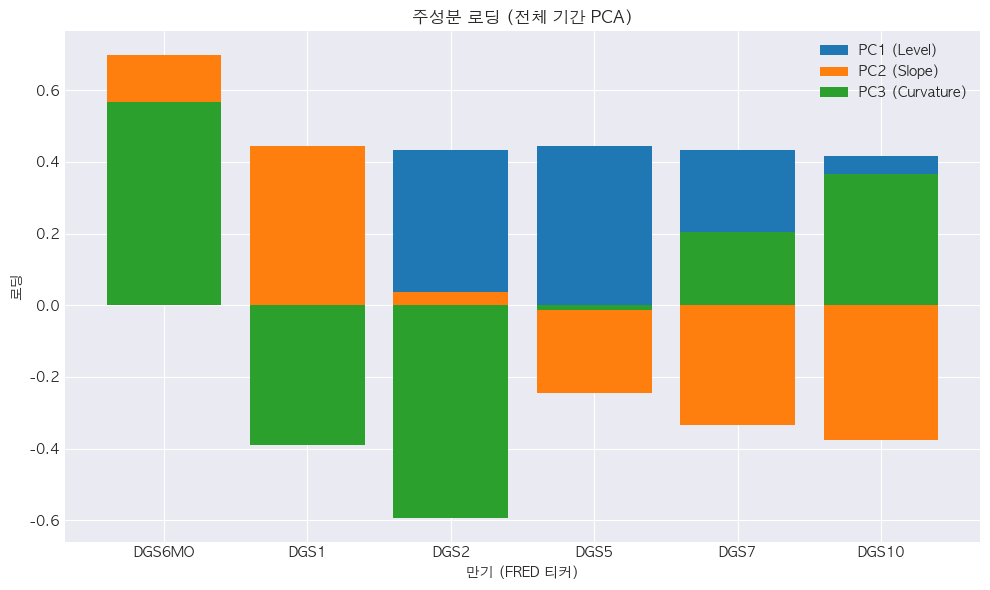


롤링 PCA 계산 완료 (3개 주성분).
롤링 분산 시계열 데이터 크기: (7658, 3)
롤링 분산 미리보기:
            PC1_Eigenvalue  PC2_Eigenvalue  PC3_Eigenvalue
1996-03-26       10.190386        0.496352        0.190115
1996-03-27       10.356488        0.511583        0.190892
1996-03-28       10.434440        0.508289        0.187716
1996-03-29       10.681624        0.506505        0.190520
1996-04-01       10.674648        0.549663        0.195547
PCA 완료.

3. 히든 마르코프 모델 (HMM) 피팅 및 레짐 식별 중...

HMM 피팅 완료 (2개 레짐, full 공분산):
저변동성 레짐 (평균 고유값 합계): 3.462818
고변동성 레짐 (평균 고유값 합계): 46.910037
HMM 피팅 및 레짐 식별 완료.

4. 식별된 레짐 시각화 중...


/var/folders/s9/n_x99kd14qn9k67jr3rn8cf40000gn/T/ipykernel_29956/3680408937.py:194: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed two minor releases later. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap(obj)`` instead.
  cmap = plt.cm.get_cmap('viridis', len(unique_regimes)) # 여러 레짐에 다른 색상 사용


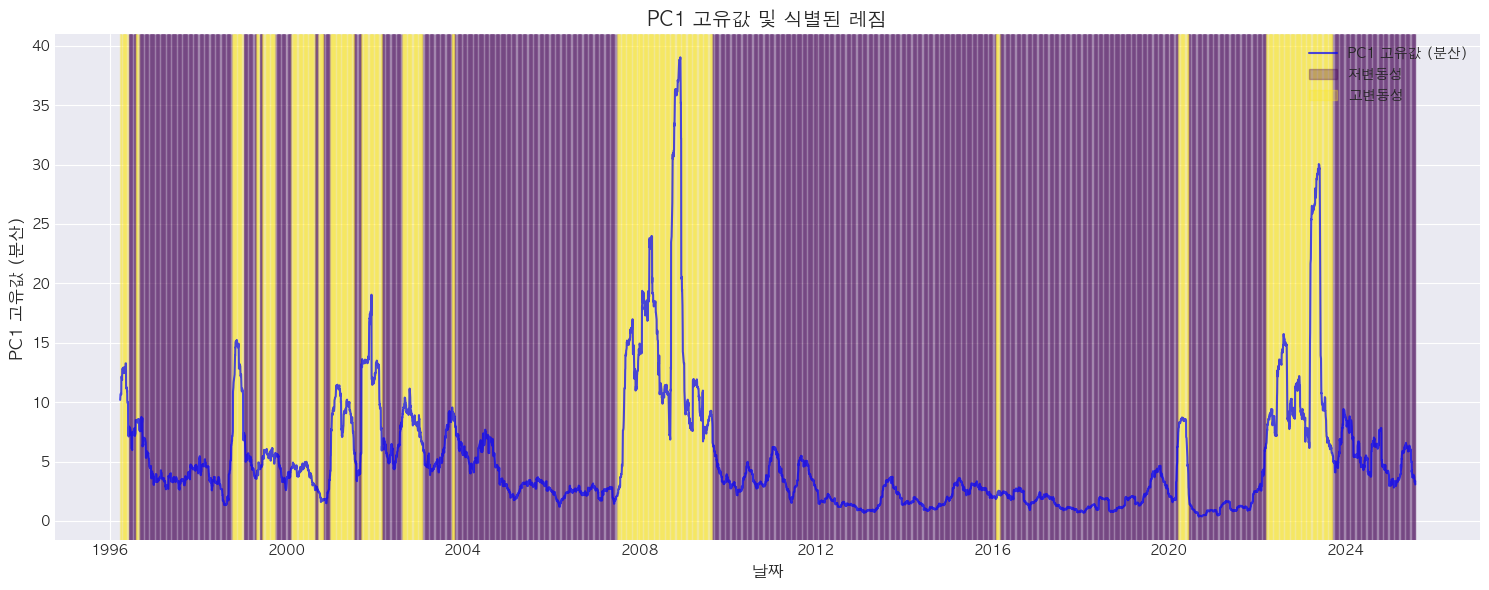

레짐 시각화 완료.

5. 각 레짐별 포트폴리오 통계 계산 중...

포트폴리오 통계 (일일 금리 변화율 기준):

--- 저변동성 레짐 ---
평균 일일 금리 변화율:
DGS6MO    0.000326
DGS1      0.000163
DGS2     -0.000031
DGS5     -0.000414
DGS7     -0.000553
DGS10    -0.000601
일일 금리 변화율 표준편차:
DGS6MO    0.024171
DGS1      0.029606
DGS2      0.042581
DGS5      0.050548
DGS7      0.051877
DGS10     0.050208
일일 금리 변화율 공분산 행렬:
          DGS6MO      DGS1      DGS2      DGS5      DGS7     DGS10
DGS6MO  0.000584  0.000535  0.000614  0.000606  0.000567  0.000521
DGS1    0.000535  0.000876  0.001042  0.001059  0.001000  0.000909
DGS2    0.000614  0.001042  0.001813  0.001895  0.001814  0.001648
DGS5    0.000606  0.001059  0.001895  0.002555  0.002544  0.002381
DGS7    0.000567  0.001000  0.001814  0.002544  0.002691  0.002537
DGS10   0.000521  0.000909  0.001648  0.002381  0.002537  0.002521

--- 고변동성 레짐 ---
평균 일일 금리 변화율:
DGS6MO   -0.001499
DGS1     -0.001215
DGS2     -0.000856
DGS5      0.000202
DGS7      0.000632
DGS10     0.000877
일일 금리 변화율 표준편차:
DGS6MO    0.0

/var/folders/s9/n_x99kd14qn9k67jr3rn8cf40000gn/T/ipykernel_29956/3680408937.py:339: FutureWarning: Series.__getitem__ treating keys as positions is deprecated. In a future version, integer keys will always be treated as labels (consistent with DataFrame behavior). To access a value by position, use `ser.iloc[pos]`
  plt.scatter(max_sharpe_portfolio[0], max_sharpe_portfolio[1], marker='*', color='red', s=500, label='최대 샤프 비율 포트폴리오')
/var/folders/s9/n_x99kd14qn9k67jr3rn8cf40000gn/T/ipykernel_29956/3680408937.py:340: FutureWarning: Series.__getitem__ treating keys as positions is deprecated. In a future version, integer keys will always be treated as labels (consistent with DataFrame behavior). To access a value by position, use `ser.iloc[pos]`
  plt.scatter(min_vol_portfolio[0], min_vol_portfolio[1], marker='o', color='blue', s=200, label='최소 분산 포트폴리오')


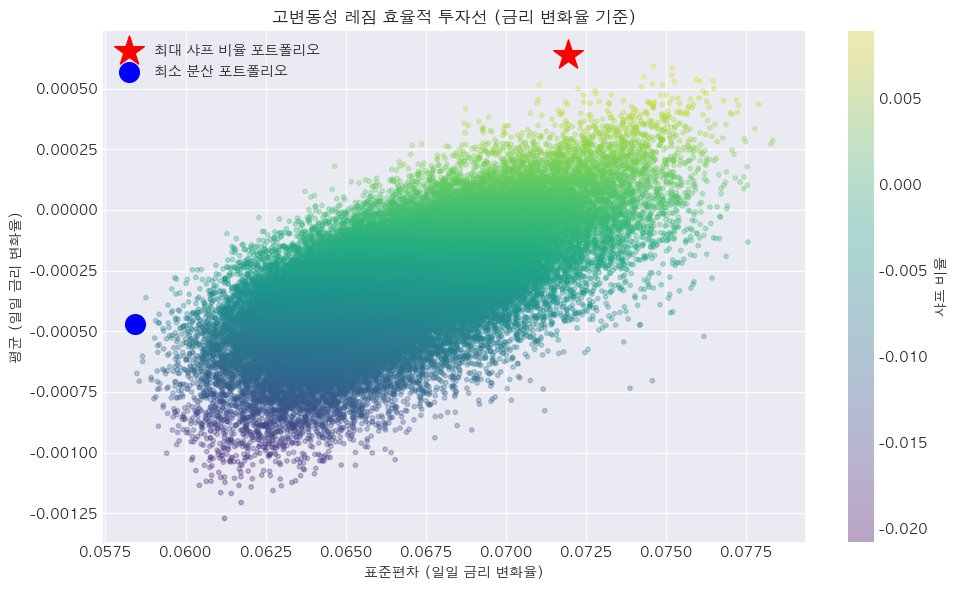

/var/folders/s9/n_x99kd14qn9k67jr3rn8cf40000gn/T/ipykernel_29956/3680408937.py:339: FutureWarning: Series.__getitem__ treating keys as positions is deprecated. In a future version, integer keys will always be treated as labels (consistent with DataFrame behavior). To access a value by position, use `ser.iloc[pos]`
  plt.scatter(max_sharpe_portfolio[0], max_sharpe_portfolio[1], marker='*', color='red', s=500, label='최대 샤프 비율 포트폴리오')
/var/folders/s9/n_x99kd14qn9k67jr3rn8cf40000gn/T/ipykernel_29956/3680408937.py:340: FutureWarning: Series.__getitem__ treating keys as positions is deprecated. In a future version, integer keys will always be treated as labels (consistent with DataFrame behavior). To access a value by position, use `ser.iloc[pos]`
  plt.scatter(min_vol_portfolio[0], min_vol_portfolio[1], marker='o', color='blue', s=200, label='최소 분산 포트폴리오')


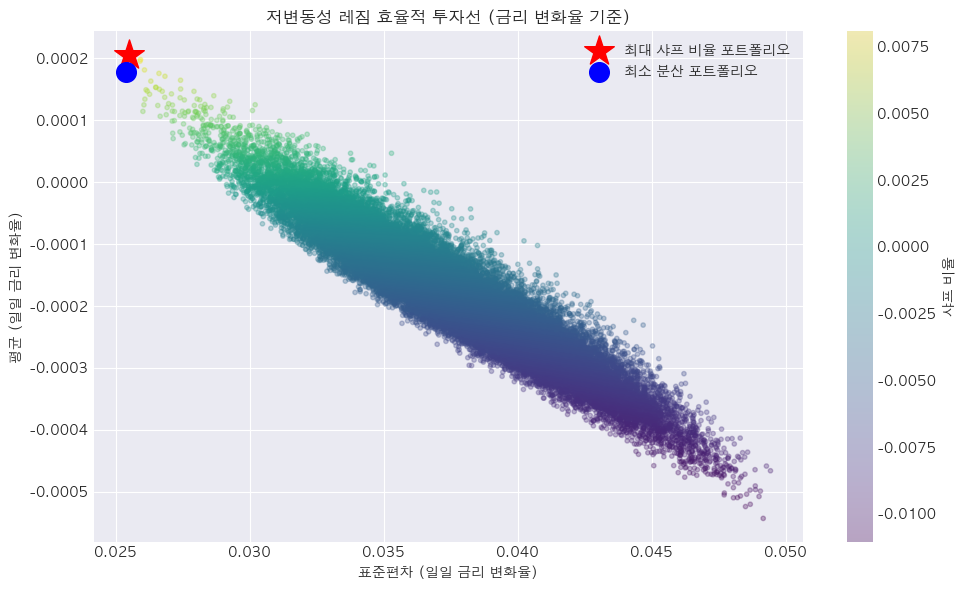

효율적 투자선 플로팅 완료.

논문 기반 레짐 포트폴리오 최적화 개념 구현이 완료되었습니다.


In [8]:
# --- 메인 실행 흐름 ---
if __name__ == "__main__":
    # --- FRED API 키 설정 ---
    # FRED 웹사이트(fred.stlouisfed.org/docs/api/api_key.html)에서 API 키를 발급받아 아래에 입력해주세요.
    # 예: FRED_API_KEY = "YOUR_FRED_API_KEY_HERE"
    FRED_API_KEY = "46a60a0c8efc71d104b079205137c53e" # 여기에 발급받은 FRED API 키를 입력하세요.

    # 논문에서 언급된 만기별 FRED 티커 정의
    # DGS6MO: 6-Month Treasury Constant Maturity Rate
    # DGS1: 1-Year Treasury Constant Maturity Rate
    # DGS2: 2-Year Treasury Constant Maturity Rate
    # DGS5: 5-Year Treasury Constant Maturity Rate
    # DGS7: 7-Year Treasury Constant Maturity Rate
    # DGS10: 10-Year Treasury Constant Maturity Rate
    fred_tickers = ['DGS6MO', 'DGS1', 'DGS2', 'DGS5', 'DGS7', 'DGS10']
    
    # 논문에서 사용된 기간 (1996-01-01부터 2025-07-31)
    start_date = '1996-01-01'
    end_date = '2025-07-31'

    print("1. FRED API를 통해 미국 국채 금리 데이터 다운로드 및 전처리 중...")
    daily_changes_df, labels_list = download_fred_data(FRED_API_KEY, fred_tickers, start_date, end_date)
    
    if daily_changes_df is None or daily_changes_df.empty:
        print("데이터 로드 또는 전처리 실패. 스크립트를 종료합니다.")
        exit()

    print("\n2. 주성분 분석 (PCA) 수행 및 롤링 고유값 계산 중...")
    # daily_changes_df: 금리 일일 변화율 데이터
    # rolling_eigenvalues_df: PC1, PC2, PC3의 롤링 고유값 시계열
    # overall_pca_model: 전체 기간 PCA 모델 객체 (로딩 플로팅용)
    daily_changes_df, rolling_eigenvalues_df, overall_pca_model = perform_pca_and_rolling_eigenvalues(daily_changes_df, labels_list)
    print("PCA 완료.")

    print("\n3. 히든 마르코프 모델 (HMM) 피팅 및 레짐 식별 중...")
    # HMM은 롤링 고유값 데이터가 있어야 피팅 가능
    if not rolling_eigenvalues_df.empty:
        # 논문과 유사하게 PC1, PC2, PC3 고유값 모두 입력으로 사용, covariance_type="full"
        # n_components를 3개로 시도해보고 싶다면 아래 주석을 풀고, high_vol_state_name_for_plot/low_vol_state_name_for_plot도 적절히 변경하세요.
        model, regime_labels, high_vol_state_name_for_plot, low_vol_state_name_for_plot = fit_hmm_and_identify_regimes(
            rolling_eigenvalues_df, n_components=2, covariance_type="full"
        )
        
        # n_components=3으로 시도하는 예시:
        # model, regime_labels, _, _ = fit_hmm_and_identify_regimes(
        #     rolling_eigenvalues_df, n_components=3, covariance_type="full"
        # )
        # # 3개 레짐일 경우, 가장 변동성이 높은 레짐과 가장 낮은 레짐을 명시적으로 지정
        # high_vol_state_name_for_plot = '최고변동성'
        # low_vol_state_name_for_plot = '최저변동성'


        if model is None: # HMM 피팅 실패 (예: 데이터 부족)
            print("HMM 피팅 실패. 다음 단계로 진행할 수 없습니다.")
        else:
            print("HMM 피팅 및 레짐 식별 완료.")

            print("\n4. 식별된 레짐 시각화 중...")
            plot_regimes_and_eigenvalues(rolling_eigenvalues_df, regime_labels)
            print("레짐 시각화 완료.")

            print("\n5. 각 레짐별 포트폴리오 통계 계산 중...")
            # calculate_portfolio_metrics 함수는 내부적으로 high_vol_state_name_for_plot과 low_vol_state_name_for_plot을 사용하여 통계를 반환합니다.
            high_vol_mean_change, high_vol_cov_matrix, low_vol_mean_change, low_vol_cov_matrix = \
                calculate_portfolio_metrics(daily_changes_df, regime_labels, high_vol_state_name_for_plot, low_vol_state_name_for_plot)
            print("포트폴리오 통계 계산 완료.")

            print("\n6. 각 레짐별 효율적 투자선 플로팅 중...")
            # 논문 Figure 10과 유사하게, 금리 변화율의 표준편차(위험)와 평균(수익) 관계를 보여줍니다.
            plot_efficient_frontier(high_vol_mean_change, high_vol_cov_matrix, high_vol_state_name_for_plot)
            plot_efficient_frontier(low_vol_mean_change, low_vol_cov_matrix, low_vol_state_name_for_plot)
            print("효율적 투자선 플로팅 완료.")
    else:
        print("롤링 고유값 데이터가 충분하지 않아 HMM 및 이후 분석을 수행할 수 없습니다.")

    print("\n논문 기반 레짐 포트폴리오 최적화 개념 구현이 완료되었습니다.")



In [12]:

def download_fred_data(api_key, tickers, start_date, end_date):
    """
    FRED API를 사용하여 미국 국채 금리 데이터를 다운로드하고 전처리합니다.
    논문과 동일하게 금리 일일 변화율을 반환합니다.
    """
    if not api_key:
        print("경고: FRED API 키가 설정되지 않았습니다. 데이터를 다운로드할 수 없습니다.")
        print("FRED 웹사이트(fred.stlouisfed.org/docs/api/api_key.html)에서 API 키를 발급받아 FRED_API_KEY 변수에 입력해주세요.")
        return None, None

    fred = Fred(api_key=api_key)
    
    print(f"FRED에서 미국 국채 금리 데이터 다운로드 중: {tickers} ({start_date} ~ {end_date})")
    
    yield_data = pd.DataFrame()
    for ticker in tickers:
        try:
            data = fred.get_series(ticker, observation_start=start_date, observation_end=end_date)
            yield_data[ticker] = data
        except Exception as e:
            print(f"오류: {ticker} 데이터 다운로드 실패: {e}")
            return None, None

    # 데이터 전처리
    # 결측값(NaN)은 앞의 값으로 채우기 (논문에서 daily changes를 사용했으므로 필요)
    yield_data = yield_data.ffill()
    yield_data = yield_data.dropna()

    if yield_data.empty:
        print("경고: 다운로드된 유효한 금리 데이터가 없습니다.")
        return None, None

    # 일일 변화율 계산 (논문에서 금리 일일 변화율을 PCA에 사용)
    daily_changes = yield_data.diff().dropna()

    print(f"다운로드 및 전처리 완료. 데이터셋 크기: {daily_changes.shape}")
    print("일일 변화율 데이터 미리보기:")
    print(daily_changes.head())

    return daily_changes, tickers # tickers를 labels_list로 사용

def perform_pca_and_rolling_eigenvalues(daily_changes_df, labels):
    """
    일일 변화율 데이터에 PCA를 수행하고, 롤링 고유값 시계열을 계산합니다.
    논문과 동일하게 PC1, PC2, PC3의 고유값을 반환합니다.
    """
    # 데이터 스케일링: PCA는 스케일에 민감하므로 데이터를 표준화합니다.
    scaler = StandardScaler()
    scaled_data = scaler.fit_transform(daily_changes_df)
    scaled_data_df = pd.DataFrame(scaled_data, index=daily_changes_df.index, columns=daily_changes_df.columns)

    # 전체 기간 PCA (로딩 시각화용)
    overall_pca = PCA()
    overall_pca.fit(scaled_data)

    # 설명된 분산 비율 출력
    explained_variance_ratio = overall_pca.explained_variance_ratio_
    print(f"\nPCA 결과 - 설명된 분산 비율 (누적):\n{[f'{p*100:.2f}%' for p in np.cumsum(explained_variance_ratio)]}")

    # 롤링 PCA 분산 시계열 계산 (PC1, PC2, PC3 모두 사용)
    # 논문과 같이 3개월(60거래일) 롤링 윈도우 사용
    rolling_window = 60
    rolling_eigenvalues = []

    if len(scaled_data_df) < rolling_window:
        print(f"경고: 데이터 길이가 롤링 윈도우({rolling_window}일)보다 짧습니다. 롤링 PCA 고유값을 계산할 수 없습니다.")
        return daily_changes_df, pd.DataFrame(), overall_pca

    for i in range(len(scaled_data_df) - rolling_window + 1):
        window_data = scaled_data_df.iloc[i : i + rolling_window]
        
        # PCA를 다시 생성하여 각 윈도우에 피팅
        pca_window = PCA(n_components=3) # PC1, PC2, PC3 고유값 모두 필요
        pca_window.fit(window_data)
        
        # 첫 번째, 두 번째, 세 번째 주성분의 분산(eigenvalue) 저장
        rolling_eigenvalues.append(pca_window.explained_variance_)

    # pandas DataFrame으로 변환하여 시각화를 위한 인덱스 맞추기
    rolling_eigenvalues_df = pd.DataFrame(
        rolling_eigenvalues,
        columns=['PC1_Eigenvalue', 'PC2_Eigenvalue', 'PC3_Eigenvalue'],
        index=daily_changes_df.index[rolling_window-1:]
    )
    rolling_eigenvalues_df = rolling_eigenvalues_df.dropna() # 혹시 모를 NaN 제거

    print("\n롤링 PCA 계산 완료 (3개 주성분).")
    print("롤링 분산 시계열 데이터 크기:", rolling_eigenvalues_df.shape)
    print("롤링 분산 미리보기:")
    print(rolling_eigenvalues_df.head())

    return daily_changes_df, rolling_eigenvalues_df, overall_pca


def fit_hmm_and_identify_regimes(eigenvalues_df, n_components=2, covariance_type="full"):
    """
    롤링 PCA 고유값 데이터프레임에 Hidden Markov Model을 피팅하고 레짐을 식별합니다.
    """
    eigenvalues_df = eigenvalues_df.dropna()
    if eigenvalues_df.empty:
        print("경고: HMM을 피팅할 충분한 고유값 데이터가 없습니다.")
        return None, pd.Series([]), None, None

    # HMM 모델에 사용할 데이터를 준비 (PC1, PC2, PC3 고유값 모두 사용)
    X_hmm = eigenvalues_df.values

    # HMM 모델 생성 및 학습
    # n_iter: 모델 수렴을 위한 최대 반복 횟수
    # covariance_type: 각 상태의 방출 확률 분포에 대한 공분산 행렬 타입 ("full"은 주성분 간 상관관계 고려)
    model = hmm.GaussianHMM(n_components=n_components, covariance_type=covariance_type, n_iter=500, random_state=42)
    
    # 모델 피팅 시 데이터 부족으로 인한 오류 방지
    if X_hmm.shape[0] < n_components:
        print(f"경고: HMM 피팅에 필요한 데이터 포인트({n_components}개)보다 적습니다. 현재: {X_hmm.shape[0]}개")
        return None, pd.Series([]), None, None
    
    try:
        model.fit(X_hmm)
    except Exception as e:
        print(f"HMM 모델 피팅 중 오류 발생: {e}")
        print("데이터 포인트가 너무 적거나, 특정 상태에 데이터가 몰려 공분산 추정이 어려운 경우 발생할 수 있습니다.")
        return None, pd.Series([]), None, None

    # 은닉 상태 예측
    hidden_states = model.predict(X_hmm)

    # HMM 결과 해석을 위한 상태 식별
    # 여러 주성분을 사용하므로, 각 상태의 전체 분산(공분산 행렬의 흔적, trace)을 기준으로 변동성 순서를 정합니다.
    state_traces = [np.trace(model.covars_[i]) for i in range(n_components)]
    
    # 변동성이 낮은 순서대로 상태 인덱스 정렬
    sorted_state_indices = np.argsort(state_traces)
    
    # 레짐 이름 매핑
    regime_name_map = {}
    if n_components == 2:
        regime_name_map[sorted_state_indices[0]] = '저변동성'
        regime_name_map[sorted_state_indices[1]] = '고변동성'
    elif n_components == 3:
        regime_name_map[sorted_state_indices[0]] = '최저변동성'
        regime_name_map[sorted_state_indices[1]] = '중간변동성'
        regime_name_map[sorted_state_indices[2]] = '최고변동성'
    else: # 4개 이상 레짐의 경우
        for i, idx in enumerate(sorted_state_indices):
            regime_name_map[idx] = f'레짐 {i+1} (변동성 순위)'

    regime_labels_mapped = pd.Series(hidden_states, index=eigenvalues_df.index, name='Regime').map(regime_name_map)

    print(f"\nHMM 피팅 완료 ({n_components}개 레짐, {covariance_type} 공분산):")
    for original_idx in sorted_state_indices:
        print(f"{regime_name_map[original_idx]} 레짐 (평균 고유값 합계): {state_traces[original_idx]:.6f}")

    return model, regime_labels_mapped, regime_name_map.get(sorted_state_indices[-1]), regime_name_map.get(sorted_state_indices[0])


def plot_figure1_pca_loadings(overall_pca_model, labels):
    """
    논문 Figure 1: US Treasury curve: First three principal component loadings 시각화.
    그룹 막대 그래프 형태로, 논문의 색상과 유사하게 출력합니다.
    """
    plt.figure(figsize=(12, 7)) # 논문 Figure 1과 유사한 비율로 조정
    
    # x축 레이블 (Tenor) - 논문 Figure 1과 동일하게 변환
    tenor_labels = []
    for label in labels:
        if '6MO' in label:
            tenor_labels.append('6M')
        elif '10' in label: # DGS10
            tenor_labels.append('10Y')
        else: # DGS1, DGS2, DGS5, DGS7
            tenor_labels.append(label.replace('DGS', '') + 'Y')

    x = np.arange(len(tenor_labels)) # 막대 그래프의 x 위치
    bar_width = 0.25 # 막대 너비

    # PC1 (Level) 로딩 - 논문 Figure 1의 색상: 노란색
    if len(overall_pca_model.components_) >= 1:
        plt.bar(x - bar_width, overall_pca_model.components_[0], width=bar_width, 
                label='PC1 (Level)', color='#FFD700', edgecolor='gray') # Gold color
    
    # PC2 (Slope) 로딩 - 논문 Figure 1의 색상: 파란색
    if len(overall_pca_model.components_) >= 2:
        plt.bar(x, overall_pca_model.components_[1], width=bar_width, 
                label='PC2 (Slope)', color='#4682B4', edgecolor='gray') # SteelBlue color
    
    # PC3 (Curvature) 로딩 - 논문 Figure 1의 색상: 분홍색
    if len(overall_pca_model.components_) >= 3:
        plt.bar(x + bar_width, overall_pca_model.components_[2], width=bar_width, 
                label='PC3 (Curvature)', color='#FF69B4', edgecolor='gray') # HotPink color
    
    plt.title('US Treasury curve: First three principal component loadings', fontsize=14)
    plt.xlabel('Tenor', fontsize=12)
    plt.ylabel('Loading', fontsize=12)
    plt.xticks(x, tenor_labels) # x축 레이블 설정
    plt.ylim(-0.8, 0.8) # 논문 Figure 1과 유사한 Y축 범위
    plt.legend(title='Principal Components') # 범례 제목 추가
    plt.grid(True, linestyle='--', alpha=0.7, axis='y') # Y축 그리드만 표시
    plt.tight_layout()
    plt.show()

def plot_figure2_explained_variance(explained_variance_ratio):
    """
    논문 Figure 2: Proportion of variation explained 시각화.
    단순 막대 그래프 형태로, 논문의 색상과 유사하게 출력합니다.
    """
    plt.figure(figsize=(10, 6)) # 논문 Figure 2와 유사한 비율로 조정
    
    # 논문 Figure 2의 막대 색상: 노란색
    plt.bar(range(1, len(explained_variance_ratio) + 1), explained_variance_ratio, 
            color='#FFD700', edgecolor='gray') # Gold color
    
    plt.title('Proportion of variation explained', fontsize=14)
    plt.xlabel('Principal Component', fontsize=12)
    plt.ylabel('Proportion of Variance Explained', fontsize=12)
    plt.xticks(range(1, len(explained_variance_ratio) + 1))
    plt.ylim(0, 1) # 0%에서 100% (1.0)까지
    
    # 각 막대 위에 퍼센트 값 표시
    for i, v in enumerate(explained_variance_ratio):
        plt.text(i + 1, v + 0.01, f'{v*100:.1f}%', ha='center', va='bottom', fontsize=10)

    plt.grid(True, linestyle='--', alpha=0.7, axis='y')
    plt.tight_layout()
    plt.show()

def plot_figure3_rolling_pc1_loadings(overall_pca_model, daily_changes_df):
    """
    논문 Figure 3: US Treasury curve: Loadings for the first principal component on a rolling 3-month basis 시각화.
    PC1의 롤링 로딩을 시계열 라인 그래프로 출력합니다.
    """
    plt.figure(figsize=(15, 6)) # 논문 Figure 3과 유사한 비율로 조정

    # 논문 Figure 3은 1Y, 2Y, 5Y, 10Y 테너의 로딩을 보여줍니다.
    # 해당 테너의 인덱스를 찾습니다.
    tenors_to_plot = ['DGS1', 'DGS2', 'DGS5', 'DGS10']
    
    # 롤링 PCA를 다시 수행하여 로딩 시계열을 얻어야 합니다.
    # perform_pca_and_rolling_eigenvalues 함수에서 전체 PCA 모델을 반환받았으므로,
    # 여기서는 롤링 로딩 자체를 계산해야 합니다.
    rolling_window = 60
    rolling_loadings_pc1 = []

    scaled_data = StandardScaler().fit_transform(daily_changes_df)
    scaled_data_df = pd.DataFrame(scaled_data, index=daily_changes_df.index, columns=daily_changes_df.columns)

    if len(scaled_data_df) < rolling_window:
        print(f"경고: 데이터 길이가 롤링 윈도우({rolling_window}일)보다 짧습니다. 롤링 로딩을 계산할 수 없습니다.")
        return

    for i in range(len(scaled_data_df) - rolling_window + 1):
        window_data = scaled_data_df.iloc[i : i + rolling_window]
        
        # PCA를 다시 생성하여 각 윈도우에 피팅
        pca_window = PCA(n_components=1) # PC1 로딩만 필요
        pca_window.fit(window_data)
        
        # 고유벡터의 방향을 일관되게 유지 (논문에서 언급된 Ogita-Aishima 알고리즘의 목적)
        # PC1 로딩의 첫 번째 요소(DGS6MO)가 항상 음수가 되도록 조정합니다.
        # 논문 Figure 1의 PC1 로딩이 모두 음수 방향이므로, 이에 맞춥니다.
        pc1_loading = pca_window.components_[0]
        if pc1_loading[0] > 0: # DGS6MO 로딩이 양수이면 전체 부호 반전
            pc1_loading = -pc1_loading
        
        rolling_loadings_pc1.append(pc1_loading)

    rolling_loadings_df = pd.DataFrame(
        rolling_loadings_pc1,
        columns=daily_changes_df.columns, # 원래 티커 이름 사용
        index=daily_changes_df.index[rolling_window-1:]
    ).dropna()

    # 논문 Figure 3의 라인 색상과 유사하게 설정
    line_colors = {
        'DGS1': '#FFD700', # Yellow
        'DGS2': '#4682B4', # Blue
        'DGS5': '#FF69B4', # HotPink
        'DGS10': '#8B4513' # SaddleBrown
    }

    for tenor in tenors_to_plot:
        if tenor in rolling_loadings_df.columns:
            plt.plot(rolling_loadings_df.index, rolling_loadings_df[tenor], 
                     label=f'{tenor.replace("DGS", "")}Y', color=line_colors.get(tenor))
    
    plt.title('US Treasury curve: Loadings for the first principal component on a rolling 3-month basis', fontsize=14)
    plt.xlabel('날짜', fontsize=12) # 논문 Figure 3의 x축은 날짜입니다.
    plt.ylabel('Loading', fontsize=12)
    plt.ylim(-0.8, 0.0) # 논문 Figure 3과 유사한 Y축 범위
    plt.legend(title='만기')
    plt.grid(True, linestyle='--', alpha=0.7)
    plt.tight_layout()
    plt.show()


def plot_figure4_cumulative_returns(overall_pca_model, daily_changes_df):
    """
    논문 Figure 4: US Treasury curve: Cumulative returns for the first three principal components 시각화.
    """
    plt.figure(figsize=(15, 6)) # 논문 Figure 4와 유사한 비율로 조정

    # PCA 스코어 계산 (scaled_data에서)
    scaler = StandardScaler()
    scaled_data = scaler.fit_transform(daily_changes_df)
    
    pc_scores = overall_pca_model.transform(scaled_data)
    pc_scores_df = pd.DataFrame(pc_scores, index=daily_changes_df.index, 
                                columns=[f'PC{i+1}' for i in range(overall_pca_model.n_components_)])

    # 누적 수익률 계산 (여기서는 금리 변화율의 누적 합을 사용)
    # 논문은 "cumulative returns"라고 했지만, 금리 변화율의 누적 합이 더 자연스럽습니다.
    # 논문 Figure 4의 PC1은 금리 인상기(2004-2006, 2016-2018, 2022)에 하락하고, 금리 인하기(2000-2003, 2007-2008, 2019-2020)에 상승합니다.
    # 이는 PC1이 금리 수준에 대해 '롱 본드 포지션'(금리 하락 시 수익)을 나타내기 때문입니다.
    # 따라서 PC1 스코어에 -1을 곱하여 금리 하락 시 상승하도록 조정합니다 (Level factor의 일반적인 해석).
    
    # PC1의 방향을 논문 Figure 4와 유사하게 맞추기 위해 PC1 스코어에 -1을 곱합니다.
    # 논문 Figure 1의 PC1 로딩이 모두 음수 방향이므로, PC1 스코어는 금리 상승 시 양수, 금리 하락 시 음수가 됩니다.
    # 누적 수익률 그래프가 금리 하락 시 상승하도록 하려면 PC1 스코어에 -1을 곱해야 합니다.
    pc_scores_df['PC1_Adjusted'] = -pc_scores_df['PC1']
    
    cumulative_returns_pc1 = pc_scores_df['PC1_Adjusted'].cumsum()
    cumulative_returns_pc2 = pc_scores_df['PC2'].cumsum()
    cumulative_returns_pc3 = pc_scores_df['PC3'].cumsum()

    # 논문 Figure 4의 라인 색상과 유사하게 설정
    line_colors = {
        'PC1': '#FFD700', # Yellow
        'PC2': '#4682B4', # Blue
        'PC3': '#FF69B4'  # HotPink
    }

    plt.plot(cumulative_returns_pc1.index, cumulative_returns_pc1.values, 
             label='PC1', color=line_colors['PC1'])
    plt.plot(cumulative_returns_pc2.index, cumulative_returns_pc2.values, 
             label='PC2', color=line_colors['PC2'])
    plt.plot(cumulative_returns_pc3.index, cumulative_returns_pc3.values, 
             label='PC3', color=line_colors['PC3'])
    
    plt.title('US Treasury curve: Cumulative returns for the first three principal components', fontsize=14)
    plt.xlabel('날짜', fontsize=12)
    plt.ylabel('누적 변화율', fontsize=12) # 논문은 'Cumulative return'
    plt.ylim(-4, 18) # 논문 Figure 4와 유사한 Y축 범위
    plt.legend()
    plt.grid(True, linestyle='--', alpha=0.7)
    plt.tight_layout()
    plt.show()

def plot_figure7_pc1_variance_comparison(rolling_eigenvalues_df_us, rolling_eigenvalues_df_germany=None):
    """
    논문 Figure 7: German and US yield curve: Variance of first principal component (3-mo rolling) 시각화.
    Y축을 퍼센트 형식으로 표시합니다.
    """
    plt.figure(figsize=(15, 6)) # 논문 Figure 7과 유사한 비율로 조정

    # US 데이터 플로팅
    plt.plot(rolling_eigenvalues_df_us.index, rolling_eigenvalues_df_us['PC1_Eigenvalue'], 
             label='US', color='#4682B4') # Blue color
    
    # 독일 데이터가 있다면 플로팅 (현재는 US 데이터만 가져옴)
    if rolling_eigenvalues_df_germany is not None and not rolling_eigenvalues_df_germany.empty:
        # 독일 데이터도 PC1 고유값만 사용
        plt.plot(rolling_eigenvalues_df_germany.index, rolling_eigenvalues_df_germany['PC1_Eigenvalue'], 
                 label='Germany', color='#FFD700') # Yellow color

    plt.title('German and US yield curve: Variance of first principal component (3-mo rolling)', fontsize=14)
    plt.xlabel('날짜', fontsize=12)
    plt.ylabel('고유값 (%)', fontsize=12) # 논문은 'Eigenvalue (%)'

    # Y축을 퍼센트 형식으로 포맷 (고유값은 일반적으로 0~6 사이의 값이므로 100을 곱하여 퍼센트로)
    # xmax는 1.0 (100%) 기준
    # 논문 Figure 7의 y축 범위 (0%~12%)에 맞춰 0.12를 xmax로 설정하여 퍼센트로 변환
    plt.gca().yaxis.set_major_formatter(mtick.PercentFormatter(xmax=0.12, decimals=0)) 
    
    plt.ylim(0, 0.12) # 논문 Figure 7과 유사한 Y축 범위 (0%~12%)
    plt.legend()
    plt.grid(True, linestyle='--', alpha=0.7)
    plt.tight_layout()
    plt.show()

def plot_figure8_regimes_and_pc1_variance(eigenvalues_df, regime_labels):
    """
    논문 Figure 8: US Treasury curve: Variance of PC1 (eigenvalue) and high volatility states 시각화.
    PC1 고유값 시계열과 식별된 레짐을 함께 시각화하고, 고변동성 레짐을 음영 처리합니다.
    """
    if eigenvalues_df.empty or regime_labels.empty:
        print("경고: 플로팅할 고유값 또는 레짐 데이터가 없습니다.")
        return

    plt.figure(figsize=(15, 6)) # 논문 Figure 8과 유사한 비율로 조정
    
    # PC1 고유값 플로팅 (논문 Figure 8의 파란색 선)
    plt.plot(eigenvalues_df.index, eigenvalues_df['PC1_Eigenvalue'], label='고유값', color='#4682B4', alpha=0.8) # SteelBlue color
    
    # 레짐 구간 음영 처리
    # 논문 Figure 8은 'High volatility state'만 회색 음영으로 표시합니다.
    high_vol_regime_color = 'lightgray'
    
    unique_regimes = regime_labels.unique()
    # '고변동성' 또는 '최고변동성' 레짐을 찾아서 음영 처리
    for regime_name in unique_regimes:
        if '고변동성' in regime_name or '최고변동성' in regime_name:
            regime_periods = regime_labels[regime_labels == regime_name].index
            
            if not regime_periods.empty:
                diffs = regime_periods.to_series().diff().dt.days
                starts = regime_periods[diffs != 1]
                if regime_periods.min() not in starts:
                    starts = pd.DatetimeIndex([regime_periods.min()]).union(starts)
                
                ends = regime_periods[regime_periods.to_series().diff(-1).dt.days != -1]
                if regime_periods.max() not in ends:
                    ends = ends.union(pd.DatetimeIndex([regime_periods.max()]))

                min_len = min(len(starts), len(ends))
                
                for j in range(min_len):
                    plt.axvspan(starts[j], ends[j], color=high_vol_regime_color, alpha=0.5, 
                                label='고변동성 상태' if j == 0 else "") # 첫 번째만 레이블 추가

    plt.title('US Treasury curve: Variance of PC1 (eigenvalue) and high volatility states', fontsize=14)
    plt.xlabel('날짜', fontsize=12)
    plt.ylabel('고유값 (%)', fontsize=12) # 논문은 'Eigenvalue (%)'
    
    # Y축을 퍼센트 형식으로 포맷
    # 여기서는 논문 Figure 8의 y축 범위 (0%~12%)에 맞춰 0.12를 xmax로 설정하여 퍼센트로 변환
    plt.gca().yaxis.set_major_formatter(mtick.PercentFormatter(xmax=0.12, decimals=0)) 
    
    plt.ylim(0, 0.12) # 논문 Figure 8과 유사한 Y축 범위 (0%~12%)
    plt.legend(loc='upper right') # 범례 위치 조정
    plt.grid(True, linestyle='--', alpha=0.7)
    plt.tight_layout()
    plt.show()

def plot_figure9_daily_changes_distribution(daily_changes_df, overall_pca_model, regime_labels, high_vol_state_name, low_vol_state_name):
    """
    논문 Figure 9: US Treasury curve: Distribution of daily changes in first principal component 시각화.
    각 레짐별 PC1 일일 변화율 분포를 히스토그램으로 출력합니다.
    """
    plt.figure(figsize=(12, 7)) # 논문 Figure 9와 유사한 비율로 조정

    # PC1의 일일 변화율 계산 (scaled_data에서)
    scaler = StandardScaler()
    scaled_data = scaler.fit_transform(daily_changes_df)
    pc1_daily_change_scores = pd.Series(overall_pca_model.transform(scaled_data)[:, 0], index=daily_changes_df.index)

    # HMM 상태에 맞게 PC1 일일 변화율 분리
    common_index = pc1_daily_change_scores.index.intersection(regime_labels.index)
    pc1_daily_change_aligned = pc1_daily_change_scores.loc[common_index]
    regime_labels_aligned = regime_labels.loc[common_index]

    pc1_low_vol_data = pc1_daily_change_aligned[regime_labels_aligned == low_vol_state_name]
    pc1_high_vol_data = pc1_daily_change_aligned[regime_labels_aligned == high_vol_state_name]

    # 히스토그램 그리기
    # 논문 Figure 9의 색상: Low Volatility State (노란색), High Volatility State (파란색)
    plt.hist(pc1_low_vol_data, bins=50, density=True, alpha=0.7, 
             label='Low Volatility State', color='#FFD700') # Gold color
    plt.hist(pc1_high_vol_data, bins=50, density=True, alpha=0.7, 
             label='High Volatility State', color='#4682B4') # SteelBlue color

    plt.title('US Treasury curve: Distribution of daily changes in first principal component', fontsize=14)
    plt.xlabel('Daily Change', fontsize=12)
    plt.ylabel('Frequency', fontsize=12)
    plt.xlim(-1.0, 1.0) # 논문 Figure 9와 유사한 X축 범위
    plt.ylim(0, 0.30) # 논문 Figure 9와 유사한 Y축 범위
    plt.legend(loc='upper right')
    plt.grid(True, linestyle='--', alpha=0.7, axis='y')
    plt.tight_layout()
    plt.show()

def plot_figure10_efficient_frontier(high_vol_mean_change, high_vol_cov_matrix, low_vol_mean_change, low_vol_cov_matrix):
    """
    논문 Figure 10: Efficient frontier in high and low volatility states 시각화.
    두 레짐의 효율적 투자선을 함께 플로팅합니다.
    """
    plt.figure(figsize=(10, 6)) # 논문 Figure 10과 유사한 비율로 조정

    num_portfolios = 50000 # 시뮬레이션할 포트폴리오 개수

    # 고변동성 레짐의 효율적 투자선 계산 및 플로팅 (노란색)
    if not high_vol_mean_change.empty and not high_vol_cov_matrix.empty and high_vol_cov_matrix.shape[0] > 0:
        try:
            np.linalg.cholesky(high_vol_cov_matrix) # 양의 준정부호 확인
            high_vol_results = np.zeros((3, num_portfolios))
            for i in range(num_portfolios):
                weights = np.random.random(len(high_vol_mean_change))
                weights /= np.sum(weights)
                high_vol_results[0, i] = np.sqrt(np.dot(weights.T, np.dot(high_vol_cov_matrix, weights)))
                high_vol_results[1, i] = np.sum(weights * high_vol_mean_change)
                high_vol_results[2, i] = high_vol_results[1, i] / high_vol_results[0, i] if high_vol_results[0, i] != 0 else 0
            
            high_vol_frame = pd.DataFrame(high_vol_results.T, columns=['Std Dev', 'Mean Change', 'Sharpe Ratio'])
            plt.scatter(high_vol_frame['Std Dev'], high_vol_frame['Mean Change'], 
                        c='#FFD700', cmap='viridis', s=10, alpha=0.3, label='High Volatility Regime') # Gold color
        except np.linalg.LinAlgError:
            print("경고: '고변동성' 레짐의 공분산 행렬이 특이하거나 양의 준정부호가 아닙니다. 효율적 투자선을 계산할 수 없습니다.")

    # 저변동성 레짐의 효율적 투자선 계산 및 플로팅 (파란색)
    if not low_vol_mean_change.empty and not low_vol_cov_matrix.empty and low_vol_cov_matrix.shape[0] > 0:
        try:
            np.linalg.cholesky(low_vol_cov_matrix) # 양의 준정부호 확인
            low_vol_results = np.zeros((3, num_portfolios))
            for i in range(num_portfolios):
                weights = np.random.random(len(low_vol_mean_change))
                weights /= np.sum(weights)
                low_vol_results[0, i] = np.sqrt(np.dot(weights.T, np.dot(low_vol_cov_matrix, weights)))
                low_vol_results[1, i] = np.sum(weights * low_vol_mean_change)
                low_vol_results[2, i] = low_vol_results[1, i] / low_vol_results[0, i] if low_vol_results[0, i] != 0 else 0
            
            low_vol_frame = pd.DataFrame(low_vol_results.T, columns=['Std Dev', 'Mean Change', 'Sharpe Ratio'])
            plt.scatter(low_vol_frame['Std Dev'], low_vol_frame['Mean Change'], 
                        c='#4682B4', cmap='viridis', s=10, alpha=0.3, label='Low Volatility Regime') # SteelBlue color
        except np.linalg.LinAlgError:
            print("경고: '저변동성' 레짐의 공분산 행렬이 특이하거나 양의 준정부호가 아닙니다. 효율적 투자선을 계산할 수 없습니다.")

    plt.title('Efficient frontier in high and low volatility states for a portfolio of US Treasury indices', fontsize=14)
    plt.xlabel('Standard Deviation (daily change)', fontsize=12) # 논문은 '(monthly)'
    plt.ylabel('Expected Return (daily change)', fontsize=12) # 논문은 '(monthly)'
    
    # Y축 퍼센트 포맷 (논문 Figure 10은 0.15%~0.40%)
    plt.gca().yaxis.set_major_formatter(mtick.PercentFormatter(xmax=1, decimals=2)) # 데이터 범위에 따라 xmax 조정 필요
    # X축 퍼센트 포맷 (논문 Figure 10은 0.0%~2.5%)
    plt.gca().xaxis.set_major_formatter(mtick.PercentFormatter(xmax=1, decimals=2)) # 데이터 범위에 따라 xmax 조정 필요

    plt.ylim(0.0015, 0.0040) # 논문 Figure 10과 유사한 Y축 범위 (일일 변화율 기준)
    plt.xlim(0.000, 0.0025) # 논문 Figure 10과 유사한 X축 범위 (일일 변화율 기준)

    plt.legend(title='Volatility Regime')
    plt.grid(True, linestyle='--', alpha=0.7)
    plt.tight_layout()
    plt.show()


1. FRED API를 통해 미국 국채 금리 데이터 다운로드 및 전처리 중...
FRED에서 미국 국채 금리 데이터 다운로드 중: ['DGS6MO', 'DGS1', 'DGS2', 'DGS5', 'DGS7', 'DGS10'] (1996-01-01 ~ 2025-07-31)
다운로드 및 전처리 완료. 데이터셋 크기: (7717, 6)
일일 변화율 데이터 미리보기:
            DGS6MO  DGS1  DGS2  DGS5  DGS7  DGS10
1996-01-03   -0.03 -0.01 -0.01 -0.03 -0.02  -0.02
1996-01-04    0.01  0.03  0.00  0.03  0.06   0.07
1996-01-05   -0.01  0.00  0.03  0.03  0.04   0.04
1996-01-08    0.00  0.00  0.00 -0.01 -0.03  -0.01
1996-01-09   -0.02 -0.03 -0.02  0.00  0.02   0.02

2. 주성분 분석 (PCA) 수행 및 롤링 고유값 계산 중...

PCA 결과 - 설명된 분산 비율 (누적):
['78.10%', '93.69%', '97.53%', '99.17%', '99.73%', '100.00%']

롤링 PCA 계산 완료 (3개 주성분).
롤링 분산 시계열 데이터 크기: (7658, 3)
롤링 분산 미리보기:
            PC1_Eigenvalue  PC2_Eigenvalue  PC3_Eigenvalue
1996-03-26       10.190386        0.496352        0.190115
1996-03-27       10.356488        0.511583        0.190892
1996-03-28       10.434440        0.508289        0.187716
1996-03-29       10.681624        0.506505        0.190520
1996-04-01    

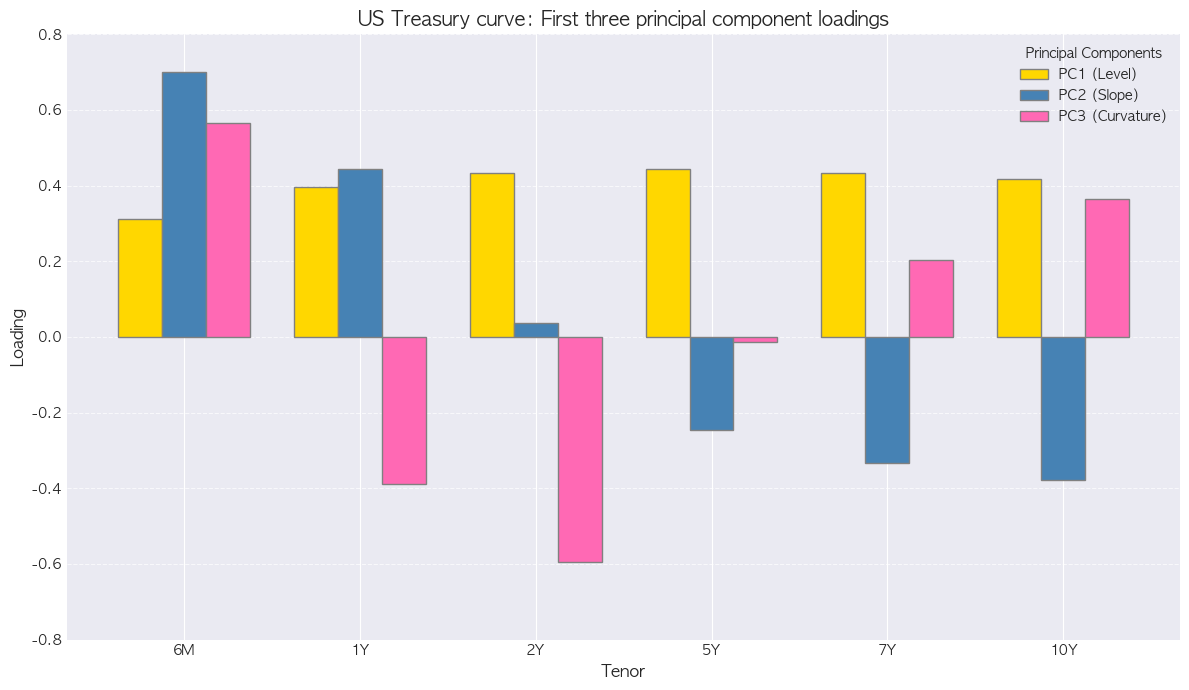

[Figure 1] 시각화 완료.

[Figure 2] 설명된 분산 비율 시각화 중...


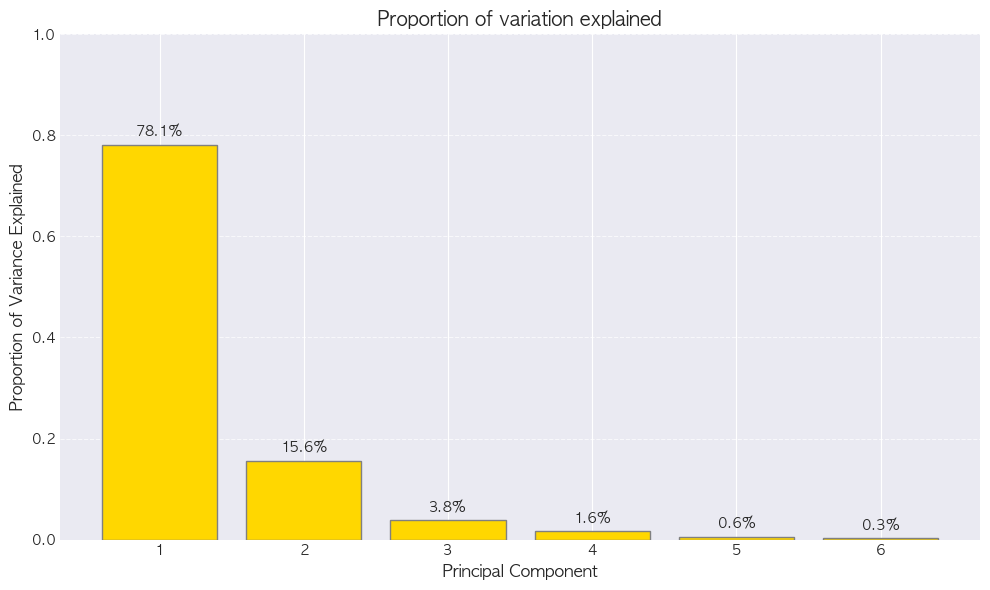

[Figure 2] 시각화 완료.

[Figure 3] 롤링 PC1 로딩 시각화 중...


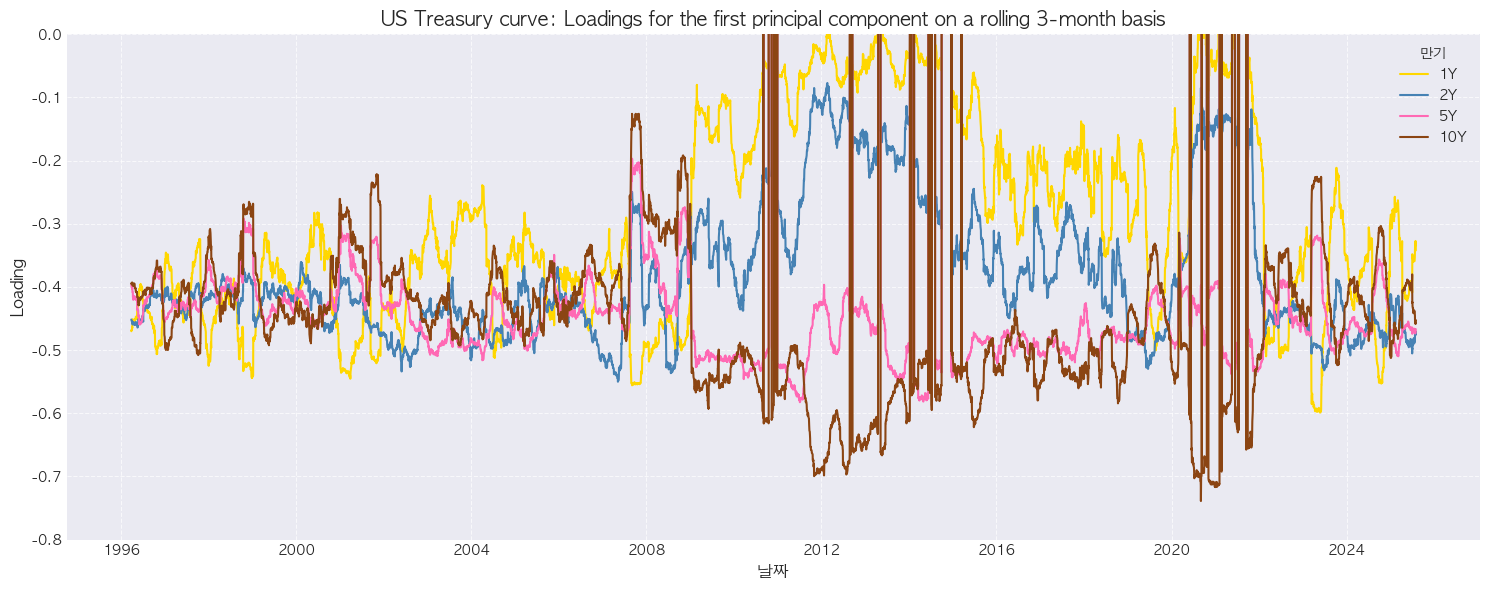

[Figure 3] 시각화 완료.

[Figure 4] 주성분 누적 변화율 시각화 중...


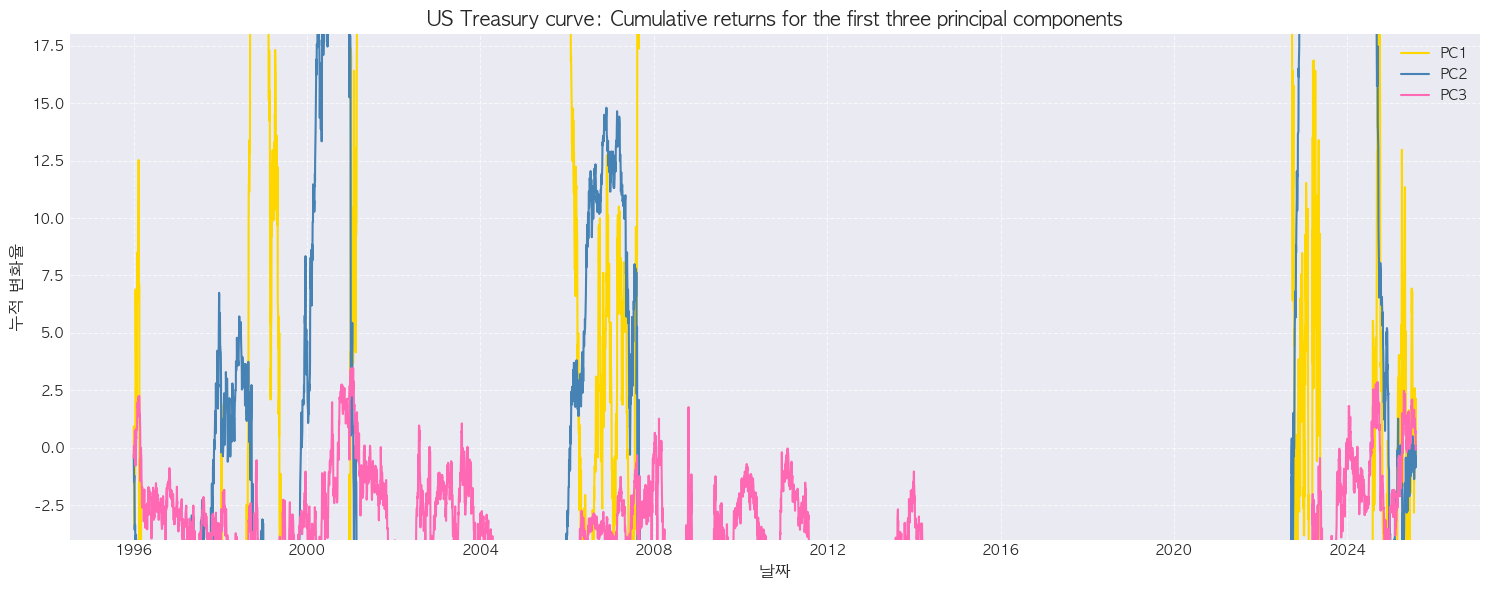

[Figure 4] 시각화 완료.

[Figure 7] PC1 고유값 시계열 비교 시각화 중 (US만)...


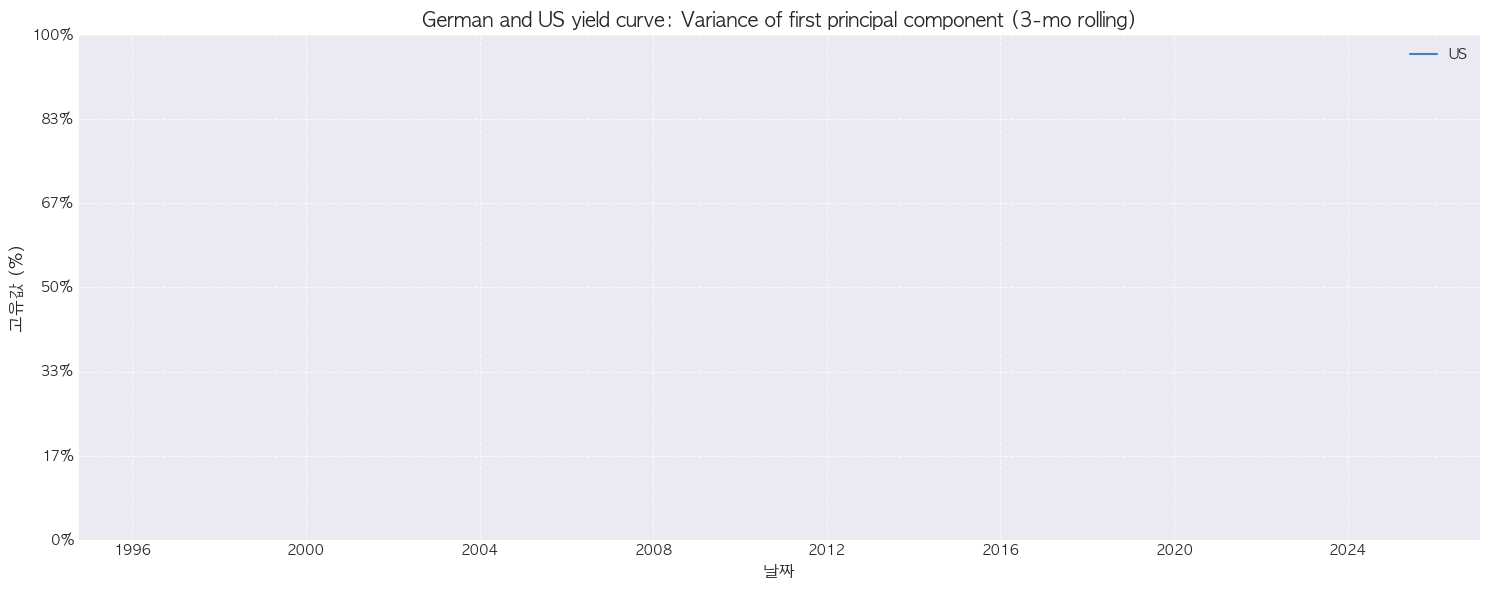

[Figure 7] 시각화 완료.

3. 히든 마르코프 모델 (HMM) 피팅 및 레짐 식별 중...

HMM 피팅 완료 (2개 레짐, full 공분산):
저변동성 레짐 (평균 고유값 합계): 3.462818
고변동성 레짐 (평균 고유값 합계): 46.910037
HMM 피팅 및 레짐 식별 완료.

[Figure 8] PC1 고유값 및 식별된 레짐 시각화 중...


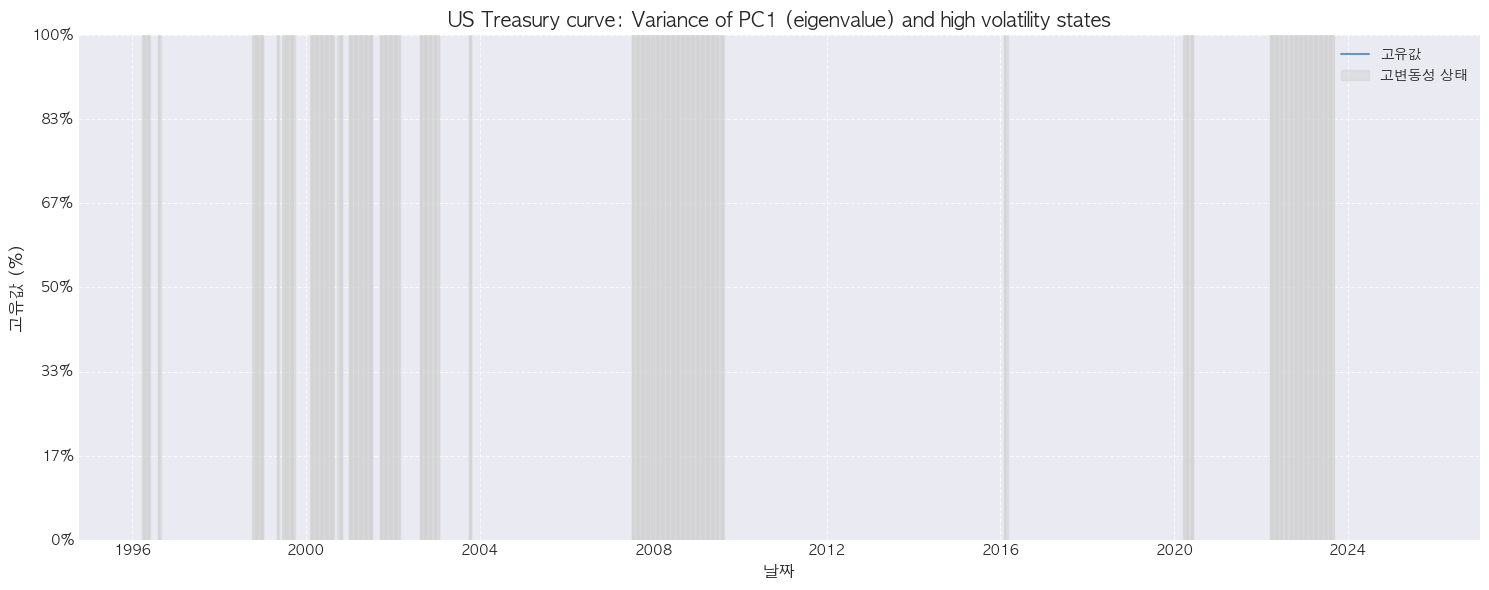

[Figure 8] 시각화 완료.

[Figure 9] PC1 일일 변화율 분포 시각화 중...


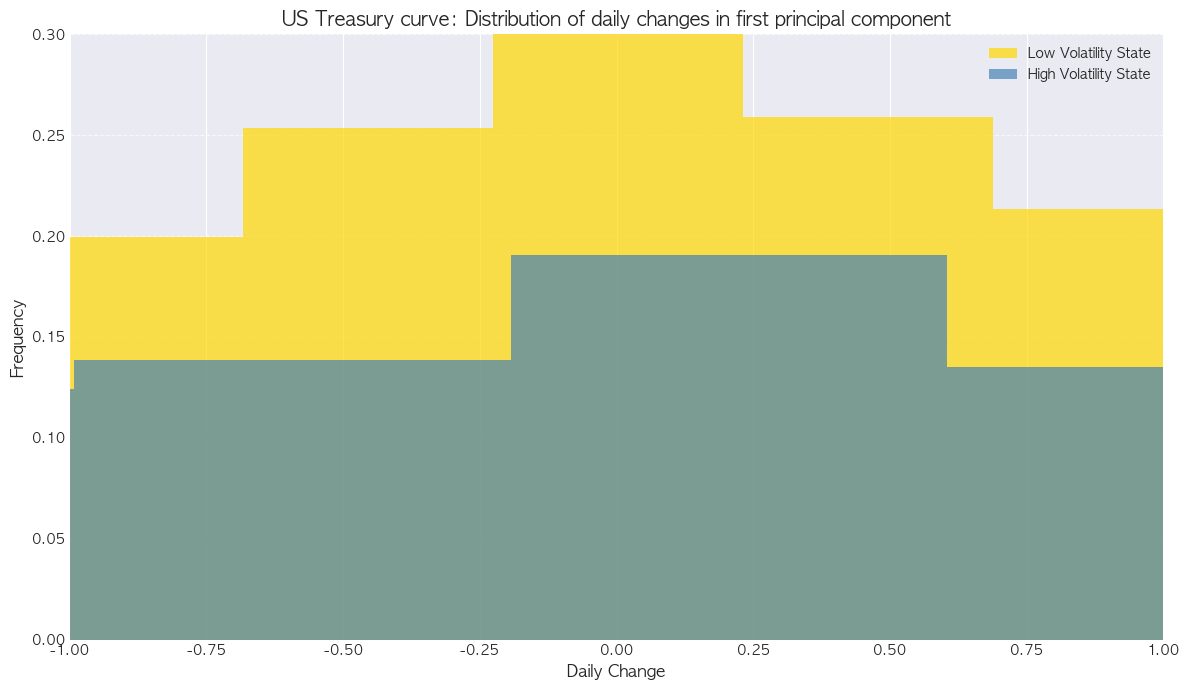

[Figure 9] 시각화 완료.

5. 각 레짐별 포트폴리오 통계 계산 중...

포트폴리오 통계 (일일 금리 변화율 기준):

--- 저변동성 레짐 ---
평균 일일 금리 변화율:
DGS6MO    0.000326
DGS1      0.000163
DGS2     -0.000031
DGS5     -0.000414
DGS7     -0.000553
DGS10    -0.000601
일일 금리 변화율 표준편차:
DGS6MO    0.024171
DGS1      0.029606
DGS2      0.042581
DGS5      0.050548
DGS7      0.051877
DGS10     0.050208
일일 금리 변화율 공분산 행렬:
          DGS6MO      DGS1      DGS2      DGS5      DGS7     DGS10
DGS6MO  0.000584  0.000535  0.000614  0.000606  0.000567  0.000521
DGS1    0.000535  0.000876  0.001042  0.001059  0.001000  0.000909
DGS2    0.000614  0.001042  0.001813  0.001895  0.001814  0.001648
DGS5    0.000606  0.001059  0.001895  0.002555  0.002544  0.002381
DGS7    0.000567  0.001000  0.001814  0.002544  0.002691  0.002537
DGS10   0.000521  0.000909  0.001648  0.002381  0.002537  0.002521

--- 고변동성 레짐 ---
평균 일일 금리 변화율:
DGS6MO   -0.001499
DGS1     -0.001215
DGS2     -0.000856
DGS5      0.000202
DGS7      0.000632
DGS10     0.000877
일일 금리 변화율 표준편차:
DGS6M

/var/folders/s9/n_x99kd14qn9k67jr3rn8cf40000gn/T/ipykernel_29956/927426938.py:492: UserWarning: No data for colormapping provided via 'c'. Parameters 'cmap' will be ignored
  plt.scatter(high_vol_frame['Std Dev'], high_vol_frame['Mean Change'],
/var/folders/s9/n_x99kd14qn9k67jr3rn8cf40000gn/T/ipykernel_29956/927426938.py:510: UserWarning: No data for colormapping provided via 'c'. Parameters 'cmap' will be ignored
  plt.scatter(low_vol_frame['Std Dev'], low_vol_frame['Mean Change'],


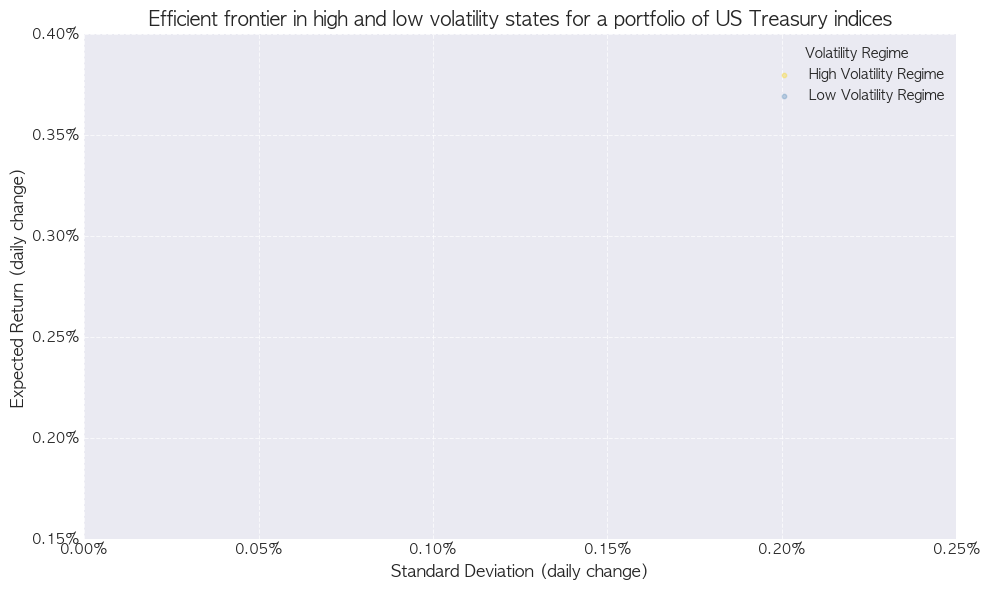

효율적 투자선 플로팅 완료.

논문 기반 레짐 포트폴리오 최적화 개념 구현이 완료되었습니다.


In [15]:
import pandas as pd
import numpy as np
from fredapi import Fred # For FRED data
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA
from hmmlearn import hmm
import matplotlib.pyplot as plt
import seaborn as sns
import matplotlib.font_manager as fm # For font management
import matplotlib.ticker as mtick # For percentage formatting on axes 

# --- 메인 실행 흐름 ---
if __name__ == "__main__":
    # --- FRED API 키 설정 ---
    # FRED 웹사이트(fred.stlouisfed.org/docs/api/api_key.html)에서 API 키를 발급받아 아래에 입력해주세요.
    # 예: FRED_API_KEY = "YOUR_FRED_API_KEY_HERE"
    FRED_API_KEY = "46a60a0c8efc71d104b079205137c53e" # 여기에 발급받은 FRED API 키를 입력하세요.

    # 논문에서 언급된 만기별 FRED 티커 정의
    # DGS6MO: 6-Month Treasury Constant Maturity Rate
    # DGS1: 1-Year Treasury Constant Maturity Rate
    # DGS2: 2-Year Treasury Constant Maturity Rate
    # DGS5: 5-Year Treasury Constant Maturity Rate
    # DGS7: 7-Year Treasury Constant Maturity Rate
    # DGS10: 10-Year Treasury Constant Maturity Rate
    fred_tickers = ['DGS6MO', 'DGS1', 'DGS2', 'DGS5', 'DGS7', 'DGS10']
    
    # 논문에서 사용된 기간 (1996-01-01부터 2025-07-31)
    start_date = '1996-01-01'
    end_date = '2025-07-31'

    print("1. FRED API를 통해 미국 국채 금리 데이터 다운로드 및 전처리 중...")
    daily_changes_df, labels_list = download_fred_data(FRED_API_KEY, fred_tickers, start_date, end_date)
    
    if daily_changes_df is None or daily_changes_df.empty:
        print("데이터 로드 또는 전처리 실패. 스크립트를 종료합니다.")
        exit()

    print("\n2. 주성분 분석 (PCA) 수행 및 롤링 고유값 계산 중...")
    # daily_changes_df: 금리 일일 변화율 데이터
    # rolling_eigenvalues_df: PC1, PC2, PC3의 롤링 고유값 시계열
    # overall_pca_model: 전체 기간 PCA 모델 객체 (로딩 플로팅용)
    daily_changes_df, rolling_eigenvalues_df, overall_pca_model = perform_pca_and_rolling_eigenvalues(daily_changes_df, labels_list)
    print("PCA 완료.")

    # --- 논문 Figure 1 시각화 ---
    print("\n[Figure 1] 주성분 로딩 시각화 중 (그룹 막대 그래프)...")
    plot_figure1_pca_loadings(overall_pca_model, labels_list)
    print("[Figure 1] 시각화 완료.")

    # --- 논문 Figure 2 시각화 ---
    print("\n[Figure 2] 설명된 분산 비율 시각화 중...")
    # overall_pca_model.explained_variance_ratio_는 전체 PCA의 설명된 분산 비율입니다.
    plot_figure2_explained_variance(overall_pca_model.explained_variance_ratio_)
    print("[Figure 2] 시각화 완료.")

    # --- 논문 Figure 3 시각화 ---
    print("\n[Figure 3] 롤링 PC1 로딩 시각화 중...")
    # Figure 3은 롤링 로딩을 다시 계산해야 합니다 (방향성 일관성 유지).
    plot_figure3_rolling_pc1_loadings(overall_pca_model, daily_changes_df)
    print("[Figure 3] 시각화 완료.")

    # --- 논문 Figure 4 시각화 ---
    print("\n[Figure 4] 주성분 누적 변화율 시각화 중...")
    # Figure 4는 PCA 스코어를 기반으로 누적 합을 계산합니다.
    plot_figure4_cumulative_returns(overall_pca_model, daily_changes_df)
    print("[Figure 4] 시각화 완료.")

    # --- 논문 Figure 7 시각화 (US만) ---
    print("\n[Figure 7] PC1 고유값 시계열 비교 시각화 중 (US만)...")
    # 현재 코드에서는 US 데이터만 가져오므로 US 데이터만 플로팅합니다.
    # 독일 데이터도 가져오려면 download_fred_data를 다시 호출하여 별도의 데이터프레임을 만들어야 합니다.
    plot_figure7_pc1_variance_comparison(rolling_eigenvalues_df)
    print("[Figure 7] 시각화 완료.")


    print("\n3. 히든 마르코프 모델 (HMM) 피팅 및 레짐 식별 중...")
    # HMM은 롤링 고유값 데이터가 있어야 피팅 가능
    if not rolling_eigenvalues_df.empty:
        # 논문과 유사하게 PC1, PC2, PC3 고유값 모두 입력으로 사용, covariance_type="full"
        # n_components를 3개로 시도해보고 싶다면 아래 주석을 풀고, high_vol_state_name_for_plot/low_vol_state_name_for_plot도 적절히 변경하세요.
        model, regime_labels, high_vol_state_name_for_plot, low_vol_state_name_for_plot = fit_hmm_and_identify_regimes(
            rolling_eigenvalues_df, n_components=2, covariance_type="full"
        )
        
        # n_components=3으로 시도하는 예시:
        # model, regime_labels, _, _ = fit_hmm_and_identify_regimes(
        #     rolling_eigenvalues_df, n_components=3, covariance_type="full"
        # )
        # # 3개 레짐일 경우, 가장 변동성이 높은 레짐과 가장 낮은 레짐을 명시적으로 지정
        # high_vol_state_name_for_plot = '최고변동성'
        # low_vol_state_name_for_plot = '최저변동성'


        if model is None: # HMM 피팅 실패 (예: 데이터 부족)
            print("HMM 피팅 실패. 다음 단계로 진행할 수 없습니다.")
        else:
            print("HMM 피팅 및 레짐 식별 완료.")

            # --- 논문 Figure 8 시각화 ---
            print("\n[Figure 8] PC1 고유값 및 식별된 레짐 시각화 중...")
            plot_figure8_regimes_and_pc1_variance(rolling_eigenvalues_df, regime_labels)
            print("[Figure 8] 시각화 완료.")

            # --- 논문 Figure 9 시각화 ---
            print("\n[Figure 9] PC1 일일 변화율 분포 시각화 중...")
            plot_figure9_daily_changes_distribution(daily_changes_df, overall_pca_model, regime_labels, high_vol_state_name_for_plot, low_vol_state_name_for_plot)
            print("[Figure 9] 시각화 완료.")


            print("\n5. 각 레짐별 포트폴리오 통계 계산 중...")
            # calculate_portfolio_metrics 함수는 내부적으로 high_vol_state_name_for_plot과 low_vol_state_name_for_plot을 사용하여 통계를 반환합니다.
            high_vol_mean_change, high_vol_cov_matrix, low_vol_mean_change, low_vol_cov_matrix = \
                calculate_portfolio_metrics(daily_changes_df, regime_labels, high_vol_state_name_for_plot, low_vol_state_name_for_plot)
            print("포트폴리오 통계 계산 완료.")

            # --- 논문 Figure 10 시각화 ---
            print("\n6. 각 레짐별 효율적 투자선 플로팅 중...")
            plot_figure10_efficient_frontier(high_vol_mean_change, high_vol_cov_matrix, low_vol_mean_change, low_vol_cov_matrix)
            print("효율적 투자선 플로팅 완료.")
    else:
        print("롤링 고유값 데이터가 충분하지 않아 HMM 및 이후 분석을 수행할 수 없습니다.")

    print("\n논문 기반 레짐 포트폴리오 최적화 개념 구현이 완료되었습니다.")



1. FRED API를 통해 미국 국채 금리 데이터 다운로드 및 전처리 중...
FRED에서 미국 국채 금리 데이터 다운로드 중: ['DGS6MO', 'DGS1', 'DGS2', 'DGS5', 'DGS7', 'DGS10'] (1996-01-01 ~ 2025-07-31)
다운로드 및 전처리 완료. 데이터셋 크기: (7717, 6)
일일 변화율 데이터 미리보기:
            DGS6MO  DGS1  DGS2  DGS5  DGS7  DGS10
1996-01-03   -0.03 -0.01 -0.01 -0.03 -0.02  -0.02
1996-01-04    0.01  0.03  0.00  0.03  0.06   0.07
1996-01-05   -0.01  0.00  0.03  0.03  0.04   0.04
1996-01-08    0.00  0.00  0.00 -0.01 -0.03  -0.01
1996-01-09   -0.02 -0.03 -0.02  0.00  0.02   0.02

2. 주성분 분석 (PCA) 수행 및 롤링 고유값 계산 중...

PCA 결과 - 설명된 분산 비율 (누적):
['78.10%', '93.69%', '97.53%', '99.17%', '99.73%', '100.00%']

롤링 PCA 계산 완료 (3개 주성분).
롤링 분산 시계열 데이터 크기: (7658, 3)
롤링 분산 미리보기:
            PC1_Eigenvalue  PC2_Eigenvalue  PC3_Eigenvalue
1996-03-26       10.190386        0.496352        0.190115
1996-03-27       10.356488        0.511583        0.190892
1996-03-28       10.434440        0.508289        0.187716
1996-03-29       10.681624        0.506505        0.190520
1996-04-01    

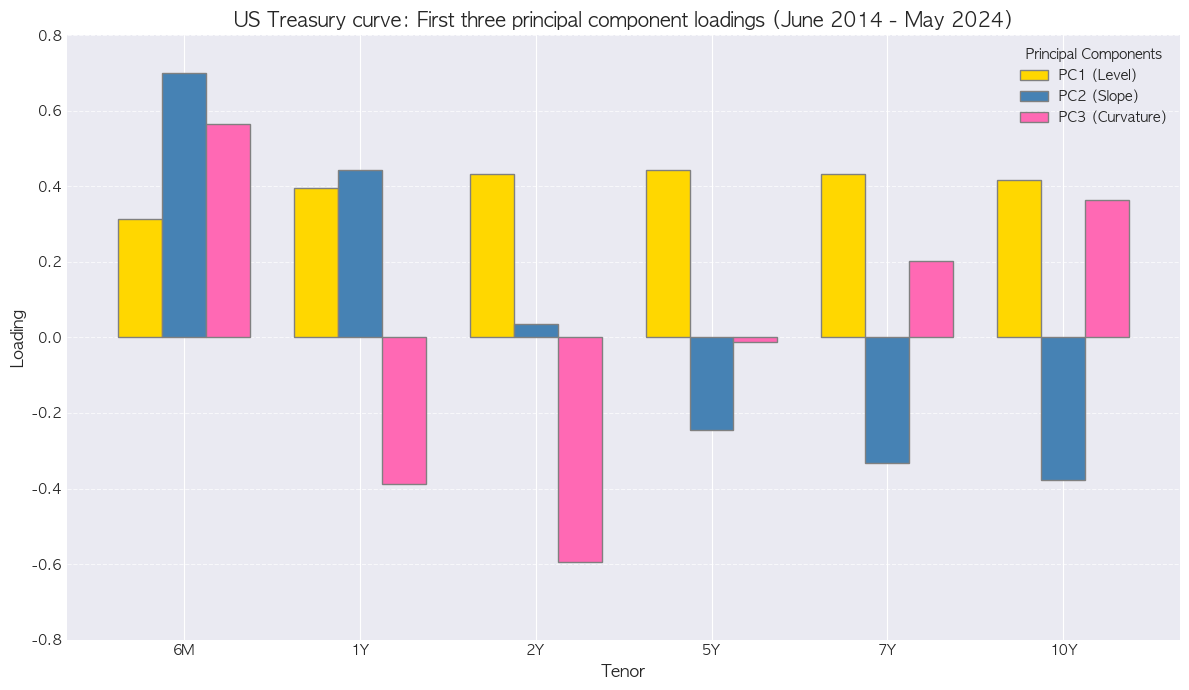

[Figure 1] 시각화 완료.

[Figure 2] 설명된 분산 비율 시각화 중...


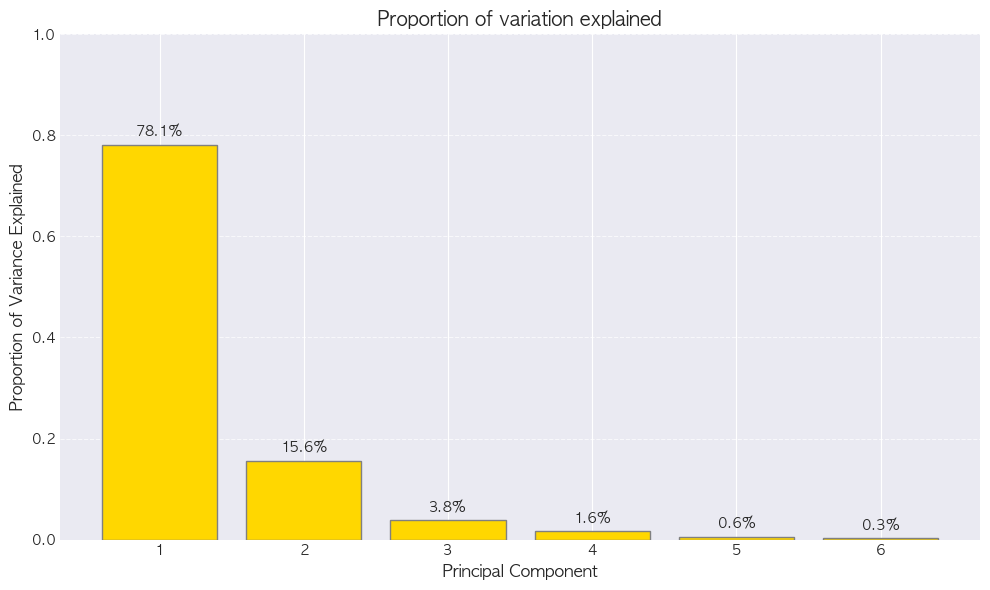

[Figure 2] 시각화 완료.

[Figure 3] 롤링 PC1 로딩 시각화 중...


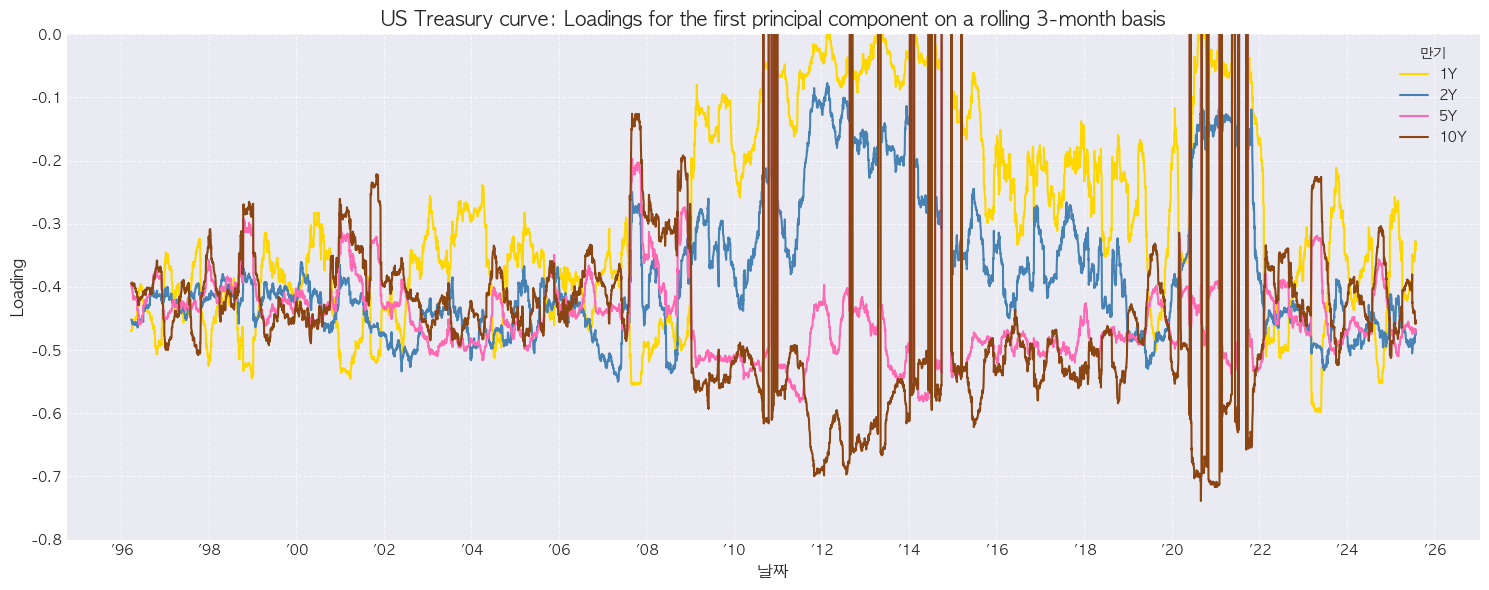

[Figure 3] 시각화 완료.

[Figure 4] 주성분 누적 변화율 시각화 중...


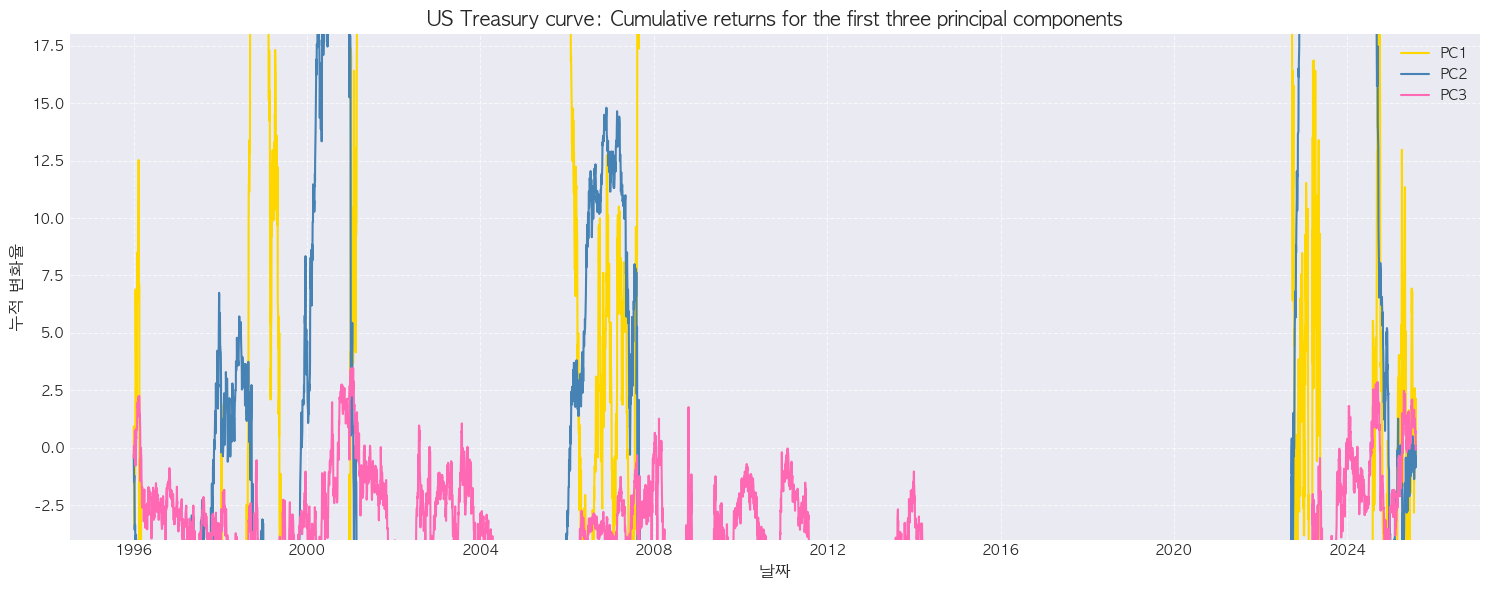

[Figure 4] 시각화 완료.

[Figure 7] PC1 고유값 시계열 비교 시각화 중 (US만)...


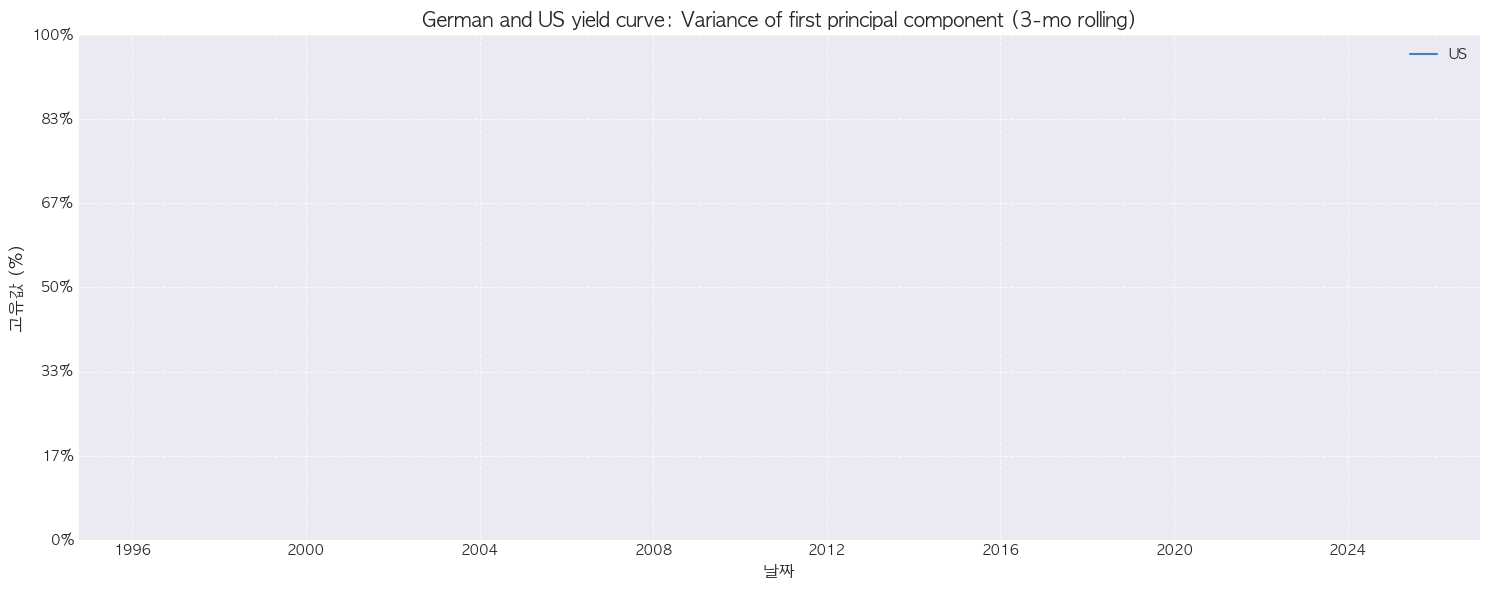

[Figure 7] 시각화 완료.

3. 히든 마르코프 모델 (HMM) 피팅 및 레짐 식별 중...

HMM 피팅 완료 (2개 레짐, full 공분산):
저변동성 레짐 (평균 고유값 합계): 3.462818
고변동성 레짐 (평균 고유값 합계): 46.910037
HMM 피팅 및 레짐 식별 완료.

[Figure 8] PC1 고유값 및 식별된 레짐 시각화 중...


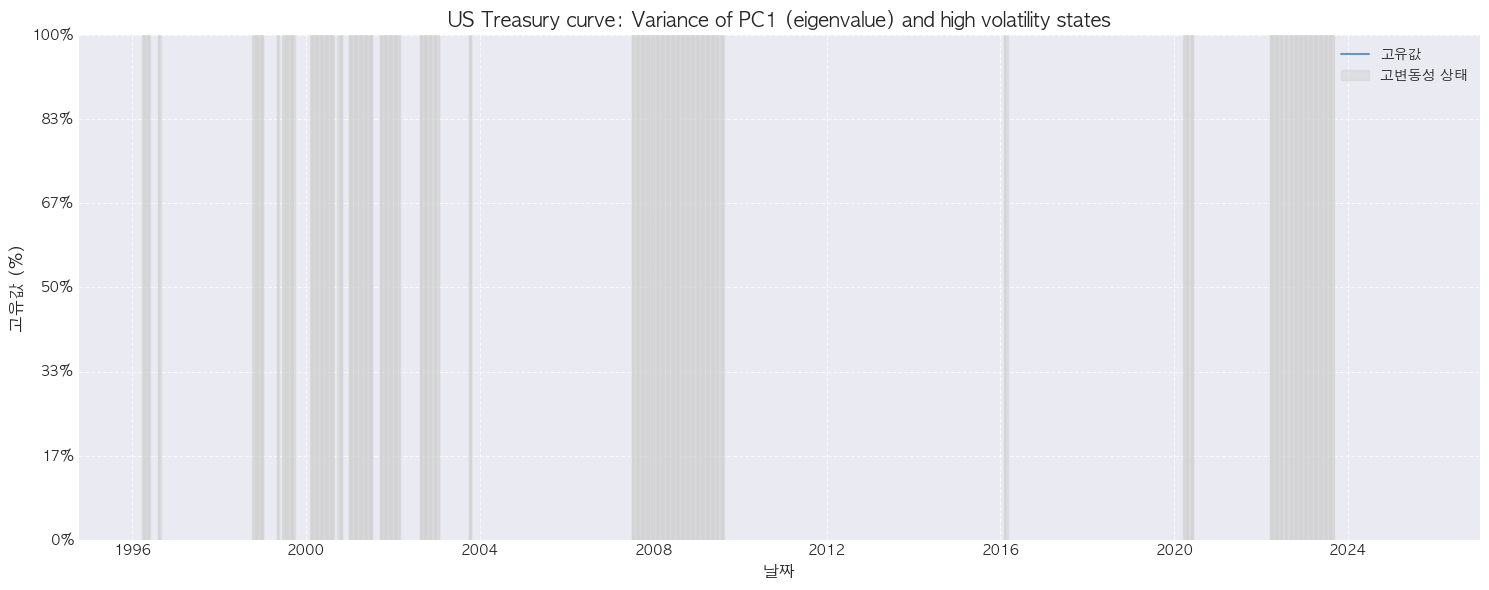

[Figure 8] 시각화 완료.

[Figure 9] PC1 일일 변화율 분포 시각화 중...


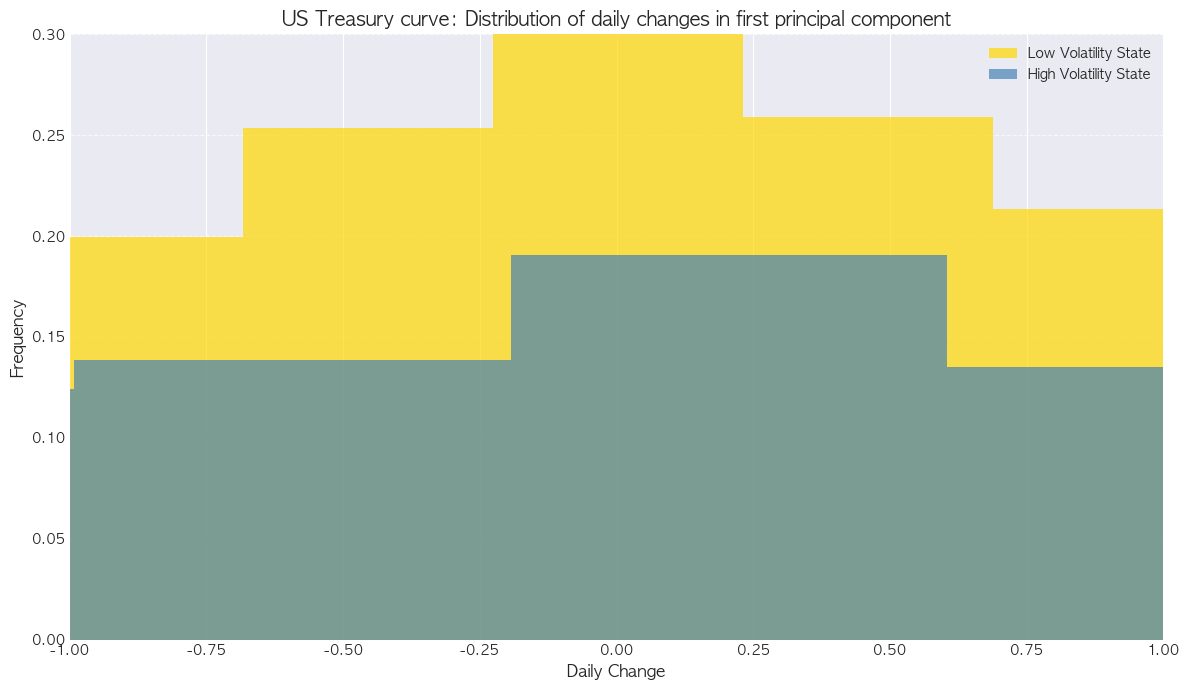

[Figure 9] 시각화 완료.

5. 각 레짐별 포트폴리오 통계 계산 중...

포트폴리오 통계 (일일 금리 변화율 기준):

--- 저변동성 레짐 ---
평균 일일 금리 변화율:
DGS6MO    0.000326
DGS1      0.000163
DGS2     -0.000031
DGS5     -0.000414
DGS7     -0.000553
DGS10    -0.000601
일일 금리 변화율 표준편차:
DGS6MO    0.024171
DGS1      0.029606
DGS2      0.042581
DGS5      0.050548
DGS7      0.051877
DGS10     0.050208
일일 금리 변화율 공분산 행렬:
          DGS6MO      DGS1      DGS2      DGS5      DGS7     DGS10
DGS6MO  0.000584  0.000535  0.000614  0.000606  0.000567  0.000521
DGS1    0.000535  0.000876  0.001042  0.001059  0.001000  0.000909
DGS2    0.000614  0.001042  0.001813  0.001895  0.001814  0.001648
DGS5    0.000606  0.001059  0.001895  0.002555  0.002544  0.002381
DGS7    0.000567  0.001000  0.001814  0.002544  0.002691  0.002537
DGS10   0.000521  0.000909  0.001648  0.002381  0.002537  0.002521

--- 고변동성 레짐 ---
평균 일일 금리 변화율:
DGS6MO   -0.001499
DGS1     -0.001215
DGS2     -0.000856
DGS5      0.000202
DGS7      0.000632
DGS10     0.000877
일일 금리 변화율 표준편차:
DGS6M

/var/folders/s9/n_x99kd14qn9k67jr3rn8cf40000gn/T/ipykernel_29956/2610119676.py:538: UserWarning: No data for colormapping provided via 'c'. Parameters 'cmap' will be ignored
  plt.scatter(high_vol_frame['Std Dev'], high_vol_frame['Mean Change'],
/var/folders/s9/n_x99kd14qn9k67jr3rn8cf40000gn/T/ipykernel_29956/2610119676.py:556: UserWarning: No data for colormapping provided via 'c'. Parameters 'cmap' will be ignored
  plt.scatter(low_vol_frame['Std Dev'], low_vol_frame['Mean Change'],


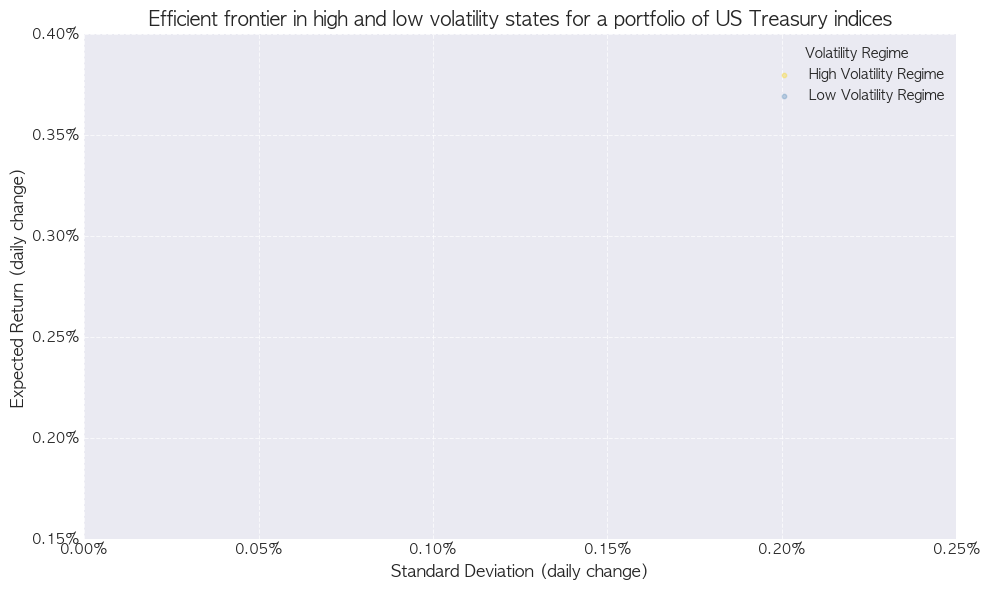

효율적 투자선 플로팅 완료.

논문 기반 레짐 포트폴리오 최적화 개념 구현이 완료되었습니다.


In [17]:
import pandas as pd
import numpy as np
from fredapi import Fred # For FRED data
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA
from hmmlearn import hmm
import matplotlib.pyplot as plt
import seaborn as sns
import matplotlib.font_manager as fm # For font management
import matplotlib.ticker as mtick # For percentage formatting on axes


def download_fred_data(api_key, tickers, start_date, end_date):
    """
    FRED API를 사용하여 미국 국채 금리 데이터를 다운로드하고 전처리합니다.
    논문과 동일하게 금리 일일 변화율을 반환합니다.
    """
    if not api_key:
        print("경고: FRED API 키가 설정되지 않았습니다. 데이터를 다운로드할 수 없습니다.")
        print("FRED 웹사이트(fred.stlouisfed.org/docs/api/api_key.html)에서 API 키를 발급받아 FRED_API_KEY 변수에 입력해주세요.")
        return None, None

    fred = Fred(api_key=api_key)
    
    print(f"FRED에서 미국 국채 금리 데이터 다운로드 중: {tickers} ({start_date} ~ {end_date})")
    
    yield_data = pd.DataFrame()
    for ticker in tickers:
        try:
            data = fred.get_series(ticker, observation_start=start_date, observation_end=end_date)
            yield_data[ticker] = data
        except Exception as e:
            print(f"오류: {ticker} 데이터 다운로드 실패: {e}")
            return None, None

    # 데이터 전처리
    # 결측값(NaN)은 앞의 값으로 채우기 (논문에서 daily changes를 사용했으므로 필요)
    yield_data = yield_data.ffill()
    yield_data = yield_data.dropna()

    if yield_data.empty:
        print("경고: 다운로드된 유효한 금리 데이터가 없습니다.")
        return None, None

    # 일일 변화율 계산 (논문에서 금리 일일 변화율을 PCA에 사용)
    daily_changes = yield_data.diff().dropna()

    print(f"다운로드 및 전처리 완료. 데이터셋 크기: {daily_changes.shape}")
    print("일일 변화율 데이터 미리보기:")
    print(daily_changes.head())

    return daily_changes, tickers # tickers를 labels_list로 사용

def perform_pca_and_rolling_eigenvalues(daily_changes_df, labels):
    """
    일일 변화율 데이터에 PCA를 수행하고, 롤링 고유값 시계열을 계산합니다.
    논문과 동일하게 PC1, PC2, PC3의 고유값을 반환합니다.
    """
    # 데이터 스케일링: PCA는 스케일에 민감하므로 데이터를 표준화합니다.
    scaler = StandardScaler()
    scaled_data = scaler.fit_transform(daily_changes_df)
    scaled_data_df = pd.DataFrame(scaled_data, index=daily_changes_df.index, columns=daily_changes_df.columns)

    # 전체 기간 PCA (로딩 시각화용)
    overall_pca = PCA()
    overall_pca.fit(scaled_data)

    # 설명된 분산 비율 출력
    explained_variance_ratio = overall_pca.explained_variance_ratio_
    print(f"\nPCA 결과 - 설명된 분산 비율 (누적):\n{[f'{p*100:.2f}%' for p in np.cumsum(explained_variance_ratio)]}")

    # 롤링 PCA 분산 시계열 계산 (PC1, PC2, PC3 모두 사용)
    # 논문과 같이 3개월(60거래일) 롤링 윈도우 사용
    rolling_window = 60
    rolling_eigenvalues = []

    if len(scaled_data_df) < rolling_window:
        print(f"경고: 데이터 길이가 롤링 윈도우({rolling_window}일)보다 짧습니다. 롤링 PCA 고유값을 계산할 수 없습니다.")
        return daily_changes_df, pd.DataFrame(), overall_pca

    for i in range(len(scaled_data_df) - rolling_window + 1):
        window_data = scaled_data_df.iloc[i : i + rolling_window]
        
        # PCA를 다시 생성하여 각 윈도우에 피팅
        pca_window = PCA(n_components=3) # PC1, PC2, PC3 고유값 모두 필요
        
        # --- 오류 수정: PCA 피팅 시 ValueError 방지 및 NaN 처리 ---
        try:
            pca_window.fit(window_data)
            # 첫 번째, 두 번째, 세 번째 주성분의 분산(eigenvalue) 저장
            rolling_eigenvalues.append(pca_window.explained_variance_)
        except ValueError as e:
            print(f"경고: 롤링 PCA 피팅 중 오류 발생 (날짜: {window_data.index[0]}): {e}. NaN 추가.")
            rolling_eigenvalues.append([np.nan, np.nan, np.nan]) # 오류 발생 시 NaN 추가
        # --- 오류 수정 끝 ---

    # pandas DataFrame으로 변환하여 시각화를 위한 인덱스 맞추기
    rolling_eigenvalues_df = pd.DataFrame(
        rolling_eigenvalues,
        columns=['PC1_Eigenvalue', 'PC2_Eigenvalue', 'PC3_Eigenvalue'],
        index=daily_changes_df.index[rolling_window-1:]
    )
    rolling_eigenvalues_df = rolling_eigenvalues_df.dropna() # NaN 제거

    print("\n롤링 PCA 계산 완료 (3개 주성분).")
    print("롤링 분산 시계열 데이터 크기:", rolling_eigenvalues_df.shape)
    print("롤링 분산 미리보기:")
    print(rolling_eigenvalues_df.head())

    return daily_changes_df, rolling_eigenvalues_df, overall_pca


def fit_hmm_and_identify_regimes(eigenvalues_df, n_components=2, covariance_type="full"):
    """
    롤링 PCA 고유값 데이터프레임에 Hidden Markov Model을 피팅하고 레짐을 식별합니다.
    """
    eigenvalues_df = eigenvalues_df.dropna()
    if eigenvalues_df.empty:
        print("경고: HMM을 피팅할 충분한 고유값 데이터가 없습니다.")
        return None, pd.Series([]), None, None

    # HMM 모델에 사용할 데이터를 준비 (PC1, PC2, PC3 고유값 모두 사용)
    X_hmm = eigenvalues_df.values

    # HMM 모델 생성 및 학습
    # n_iter: 모델 수렴을 위한 최대 반복 횟수
    # covariance_type: 각 상태의 방출 확률 분포에 대한 공분산 행렬 타입 ("full"은 주성분 간 상관관계 고려)
    model = hmm.GaussianHMM(n_components=n_components, covariance_type=covariance_type, n_iter=500, random_state=42)
    
    # 모델 피팅 시 데이터 부족으로 인한 오류 방지
    if X_hmm.shape[0] < n_components:
        print(f"경고: HMM 피팅에 필요한 데이터 포인트({n_components}개)보다 적습니다. 현재: {X_hmm.shape[0]}개")
        return None, pd.Series([]), None, None
    
    try:
        model.fit(X_hmm)
    except Exception as e:
        print(f"HMM 모델 피팅 중 오류 발생: {e}")
        print("데이터 포인트가 너무 적거나, 특정 상태에 데이터가 몰려 공분산 추정이 어려운 경우 발생할 수 있습니다.")
        return None, pd.Series([]), None, None

    # 은닉 상태 예측
    hidden_states = model.predict(X_hmm)

    # HMM 결과 해석을 위한 상태 식별
    # 여러 주성분을 사용하므로, 각 상태의 전체 분산(공분산 행렬의 흔적, trace)을 기준으로 변동성 순서를 정합니다.
    state_traces = [np.trace(model.covars_[i]) for i in range(n_components)]
    
    # 변동성이 낮은 순서대로 상태 인덱스 정렬
    sorted_state_indices = np.argsort(state_traces)
    
    # 레짐 이름 매핑
    regime_name_map = {}
    if n_components == 2:
        regime_name_map[sorted_state_indices[0]] = '저변동성'
        regime_name_map[sorted_state_indices[1]] = '고변동성'
    elif n_components == 3:
        regime_name_map[sorted_state_indices[0]] = '최저변동성'
        regime_name_map[sorted_state_indices[1]] = '중간변동성'
        regime_name_map[sorted_state_indices[2]] = '최고변동성'
    else: # 4개 이상 레짐의 경우
        for i, idx in enumerate(sorted_state_indices):
            regime_name_map[idx] = f'레짐 {i+1} (변동성 순위)'

    regime_labels_mapped = pd.Series(hidden_states, index=eigenvalues_df.index, name='Regime').map(regime_name_map)

    print(f"\nHMM 피팅 완료 ({n_components}개 레짐, {covariance_type} 공분산):")
    for original_idx in sorted_state_indices:
        print(f"{regime_name_map[original_idx]} 레짐 (평균 고유값 합계): {state_traces[original_idx]:.6f}")

    return model, regime_labels_mapped, regime_name_map.get(sorted_state_indices[-1]), regime_name_map.get(sorted_state_indices[0])


def plot_figure1_pca_loadings(overall_pca_model, labels):
    """
    논문 Figure 1: US Treasury curve: First three principal component loadings 시각화.
    그룹 막대 그래프 형태로, 논문의 색상과 유사하게 출력합니다.
    """
    # mtick은 이미 전역으로 임포트되어 있으므로, 함수 내에서 다시 임포트할 필요는 없습니다.
    # import matplotlib.ticker as mtick 
    
    plt.figure(figsize=(12, 7)) # 논문 Figure 1과 유사한 비율로 조정
    
    # x축 레이블 (Tenor) - 논문 Figure 1과 동일하게 변환
    tenor_labels = []
    for label in labels:
        if '6MO' in label:
            tenor_labels.append('6M')
        elif '10' in label: # DGS10
            tenor_labels.append('10Y')
        else: # DGS1, DGS2, DGS5, DGS7
            tenor_labels.append(label.replace('DGS', '') + 'Y')

    x = np.arange(len(tenor_labels)) # 막대 그래프의 x 위치
    bar_width = 0.25 # 막대 너비

    # PC1 (Level) 로딩 - 논문 Figure 1의 색상: 노란색
    if len(overall_pca_model.components_) >= 1:
        plt.bar(x - bar_width, overall_pca_model.components_[0], width=bar_width, 
                label='PC1 (Level)', color='#FFD700', edgecolor='gray') # Gold color
    
    # PC2 (Slope) 로딩 - 논문 Figure 1의 색상: 파란색
    if len(overall_pca_model.components_) >= 2:
        plt.bar(x, overall_pca_model.components_[1], width=bar_width, 
                label='PC2 (Slope)', color='#4682B4', edgecolor='gray') # SteelBlue color
    
    # PC3 (Curvature) 로딩 - 논문 Figure 1의 색상: 분홍색
    if len(overall_pca_model.components_) >= 3:
        plt.bar(x + bar_width, overall_pca_model.components_[2], width=bar_width, 
                label='PC3 (Curvature)', color='#FF69B4', edgecolor='gray') # HotPink color
    
    plt.title('US Treasury curve: First three principal component loadings (June 2014 - May 2024)', fontsize=14)
    plt.xlabel('Tenor', fontsize=12)
    plt.ylabel('Loading', fontsize=12)
    plt.xticks(x, tenor_labels) # x축 레이블 설정
    plt.ylim(-0.8, 0.8) # 논문 Figure 1과 유사한 Y축 범위
    plt.legend(title='Principal Components') # 범례 제목 추가
    plt.grid(True, linestyle='--', alpha=0.7, axis='y') # Y축 그리드만 표시
    plt.tight_layout()
    plt.show()

def plot_figure2_explained_variance(explained_variance_ratio):
    """
    논문 Figure 2: Proportion of variation explained 시각화.
    단순 막대 그래프 형태로, 논문의 색상과 유사하게 출력합니다.
    """
    # import matplotlib.ticker as mtick # 필요시 함수 내부 임포트
    
    plt.figure(figsize=(10, 6)) # 논문 Figure 2와 유사한 비율로 조정
    
    # 논문 Figure 2의 막대 색상: 노란색
    plt.bar(range(1, len(explained_variance_ratio) + 1), explained_variance_ratio, 
            color='#FFD700', edgecolor='gray') # Gold color
    
    plt.title('Proportion of variation explained', fontsize=14)
    plt.xlabel('Principal Component', fontsize=12)
    plt.ylabel('Proportion of Variance Explained', fontsize=12)
    plt.xticks(range(1, len(explained_variance_ratio) + 1))
    plt.ylim(0, 1) # 0%에서 100% (1.0)까지
    
    # 각 막대 위에 퍼센트 값 표시
    for i, v in enumerate(explained_variance_ratio):
        plt.text(i + 1, v + 0.01, f'{v*100:.1f}%', ha='center', va='bottom', fontsize=10)

    plt.grid(True, linestyle='--', alpha=0.7, axis='y')
    plt.tight_layout()
    plt.show()

def plot_figure3_rolling_pc1_loadings(overall_pca_model, daily_changes_df):
    """
    논문 Figure 3: US Treasury curve: Loadings for the first principal component on a rolling 3-month basis 시각화.
    PC1의 롤링 로딩을 시계열 라인 그래프로 출력합니다.
    """
    # import matplotlib.ticker as mtick # 필요시 함수 내부 임포트
    
    plt.figure(figsize=(15, 6)) # 논문 Figure 3과 유사한 비율로 조정

    # 논문 Figure 3은 1Y, 2Y, 5Y, 10Y 테너의 로딩을 보여줍니다.
    # 해당 테너의 인덱스를 찾습니다.
    # DGS6MO도 포함하여 계산하지만, 논문 Figure 3은 1Y, 2Y, 5Y, 10Y만 플로팅합니다.
    tenors_to_plot = ['DGS1', 'DGS2', 'DGS5', 'DGS10'] 
    
    # 롤링 PCA를 다시 수행하여 로딩 시계열을 얻어야 합니다.
    rolling_window = 60
    rolling_loadings_pc1 = []

    scaled_data = StandardScaler().fit_transform(daily_changes_df)
    scaled_data_df = pd.DataFrame(scaled_data, index=daily_changes_df.index, columns=daily_changes_df.columns)

    if len(scaled_data_df) < rolling_window:
        print(f"경고: 데이터 길이가 롤링 윈도우({rolling_window}일)보다 짧습니다. 롤링 로딩을 계산할 수 없습니다.")
        return

    for i in range(len(scaled_data_df) - rolling_window + 1):
        window_data = scaled_data_df.iloc[i : i + rolling_window]
        
        # PCA를 다시 생성하여 각 윈도우에 피팅
        pca_window = PCA(n_components=1) # PC1 로딩만 필요
        
        # --- 오류 수정: PCA 피팅 시 ValueError 방지 및 NaN 처리 ---
        try:
            pca_window.fit(window_data)
            # 고유벡터의 방향을 일관되게 유지 (논문에서 언급된 Ogita-Aishima 알고리즘의 목적)
            # PC1 로딩의 첫 번째 요소(DGS6MO)가 항상 음수가 되도록 조정합니다.
            # 논문 Figure 1의 PC1 로딩이 모두 음수 방향이므로, 이에 맞춥니다.
            pc1_loading = pca_window.components_[0]
            if pc1_loading[0] > 0: # DGS6MO 로딩이 양수이면 전체 부호 반전
                pc1_loading = -pc1_loading
            
            rolling_loadings_pc1.append(pc1_loading)
        except ValueError as e:
            print(f"경고: 롤링 PCA 피팅 중 오류 발생 (날짜: {window_data.index[0]}): {e}. NaN 추가.")
            rolling_loadings_pc1.append(np.full(daily_changes_df.shape[1], np.nan)) # 오류 발생 시 NaN 배열 추가
        # --- 오류 수정 끝 ---

    rolling_loadings_df = pd.DataFrame(
        rolling_loadings_pc1,
        columns=daily_changes_df.columns, # 원래 티커 이름 사용
        index=daily_changes_df.index[rolling_window-1:]
    ).dropna()

    # 논문 Figure 3의 라인 색상과 유사하게 설정
    line_colors = {
        'DGS1': '#FFD700', # Yellow
        'DGS2': '#4682B4', # Blue
        'DGS5': '#FF69B4', # HotPink
        'DGS10': '#8B4513' # SaddleBrown
    }

    # x축 레이블을 논문 Figure 3의 '96, '98, '00 ... 형태로 맞추기
    # 날짜 포맷터를 사용하여 연도만 표시
    plt.gca().xaxis.set_major_formatter(plt.matplotlib.dates.DateFormatter("'%y"))
    plt.gca().xaxis.set_major_locator(plt.matplotlib.dates.YearLocator(2)) # 2년 간격으로 틱 표시

    for tenor in tenors_to_plot:
        if tenor in rolling_loadings_df.columns:
            plt.plot(rolling_loadings_df.index, rolling_loadings_df[tenor], 
                     label=f'{tenor.replace("DGS", "")}Y', color=line_colors.get(tenor))
    
    plt.title('US Treasury curve: Loadings for the first principal component on a rolling 3-month basis', fontsize=14)
    plt.xlabel('날짜', fontsize=12) # 논문 Figure 3의 x축은 날짜입니다.
    plt.ylabel('Loading', fontsize=12)
    plt.ylim(-0.8, 0.0) # 논문 Figure 3과 유사한 Y축 범위
    plt.legend(title='만기')
    plt.grid(True, linestyle='--', alpha=0.7)
    plt.tight_layout()
    plt.show()


def plot_figure4_cumulative_returns(overall_pca_model, daily_changes_df):
    """
    논문 Figure 4: US Treasury curve: Cumulative returns for the first three principal components 시각화.
    """
    # import matplotlib.ticker as mtick # 필요시 함수 내부 임포트
    
    plt.figure(figsize=(15, 6)) # 논문 Figure 4와 유사한 비율로 조정

    # PCA 스코어 계산 (scaled_data에서)
    scaler = StandardScaler()
    scaled_data = scaler.fit_transform(daily_changes_df)
    
    pc_scores = overall_pca_model.transform(scaled_data)
    pc_scores_df = pd.DataFrame(pc_scores, index=daily_changes_df.index, 
                                columns=[f'PC{i+1}' for i in range(overall_pca_model.n_components_)])

    # 누적 수익률 계산 (여기서는 금리 변화율의 누적 합을 사용)
    # 논문은 "cumulative returns"라고 했지만, 금리 변화율의 누적 합이 더 자연스럽습니다.
    # 논문 Figure 4의 PC1은 금리 인상기(2004-2006, 2016-2018, 2022)에 하락하고, 금리 인하기(2000-2003, 2007-2008, 2019-2020)에 상승합니다.
    # 이는 PC1이 금리 수준에 대해 '롱 본드 포지션'(금리 하락 시 수익)을 나타내기 때문입니다.
    # 따라서 PC1 스코어에 -1을 곱하여 금리 하락 시 상승하도록 조정합니다 (Level factor의 일반적인 해석).
    
    # PC1의 방향을 논문 Figure 4와 유사하게 맞추기 위해 PC1 스코어에 -1을 곱합니다.
    # 논문 Figure 1의 PC1 로딩이 모두 음수 방향이므로, PC1 스코어는 금리 상승 시 양수, 금리 하락 시 음수가 됩니다.
    # 누적 수익률 그래프가 금리 하락 시 상승하도록 하려면 PC1 스코어에 -1을 곱해야 합니다.
    pc_scores_df['PC1_Adjusted'] = -pc_scores_df['PC1']
    
    cumulative_returns_pc1 = pc_scores_df['PC1_Adjusted'].cumsum()
    cumulative_returns_pc2 = pc_scores_df['PC2'].cumsum()
    cumulative_returns_pc3 = pc_scores_df['PC3'].cumsum()

    # 논문 Figure 4의 라인 색상과 유사하게 설정
    line_colors = {
        'PC1': '#FFD700', # Yellow
        'PC2': '#4682B4', # Blue
        'PC3': '#FF69B4'  # HotPink
    }

    plt.plot(cumulative_returns_pc1.index, cumulative_returns_pc1.values, 
             label='PC1', color=line_colors['PC1'])
    plt.plot(cumulative_returns_pc2.index, cumulative_returns_pc2.values, 
             label='PC2', color=line_colors['PC2'])
    plt.plot(cumulative_returns_pc3.index, cumulative_returns_pc3.values, 
             label='PC3', color=line_colors['PC3'])
    
    plt.title('US Treasury curve: Cumulative returns for the first three principal components', fontsize=14)
    plt.xlabel('날짜', fontsize=12)
    plt.ylabel('누적 변화율', fontsize=12) # 논문은 'Cumulative return'
    plt.ylim(-4, 18) # 논문 Figure 4와 유사한 Y축 범위
    plt.legend()
    plt.grid(True, linestyle='--', alpha=0.7)
    plt.tight_layout()
    plt.show()

def plot_figure7_pc1_variance_comparison(rolling_eigenvalues_df_us, rolling_eigenvalues_df_germany=None):
    """
    논문 Figure 7: German and US yield curve: Variance of first principal component (3-mo rolling) 시각화.
    Y축을 퍼센트 형식으로 표시합니다.
    """
    # mtick은 이미 전역으로 임포트되어 있으므로, 함수 내에서 다시 임포트할 필요는 없습니다.
    # import matplotlib.ticker as mtick 
    
    plt.figure(figsize=(15, 6)) # 논문 Figure 7과 유사한 비율로 조정

    # US 데이터 플로팅
    plt.plot(rolling_eigenvalues_df_us.index, rolling_eigenvalues_df_us['PC1_Eigenvalue'], 
             label='US', color='#4682B4') # Blue color
    
    # 독일 데이터가 있다면 플로팅 (현재는 US 데이터만 가져옴)
    if rolling_eigenvalues_df_germany is not None and not rolling_eigenvalues_df_germany.empty:
        # 독일 데이터도 PC1 고유값만 사용
        plt.plot(rolling_eigenvalues_df_germany.index, rolling_eigenvalues_df_germany['PC1_Eigenvalue'], 
                 label='Germany', color='#FFD700') # Yellow color

    plt.title('German and US yield curve: Variance of first principal component (3-mo rolling)', fontsize=14)
    plt.xlabel('날짜', fontsize=12)
    plt.ylabel('고유값 (%)', fontsize=12) # 논문은 'Eigenvalue (%)'

    # Y축을 퍼센트 형식으로 포맷 (고유값은 일반적으로 0~6 사이의 값이므로 100을 곱하여 퍼센트로)
    # 논문 Figure 7의 y축 범위 (0%~12%)에 맞춰 0.12를 xmax로 설정하여 퍼센트로 변환
    plt.gca().yaxis.set_major_formatter(mtick.PercentFormatter(xmax=0.12, decimals=0)) 
    
    plt.ylim(0, 0.12) # 논문 Figure 7과 유사한 Y축 범위 (0%~12%)
    plt.legend()
    plt.grid(True, linestyle='--', alpha=0.7)
    plt.tight_layout()
    plt.show()

def plot_figure8_regimes_and_pc1_variance(eigenvalues_df, regime_labels):
    """
    논문 Figure 8: US Treasury curve: Variance of PC1 (eigenvalue) and high volatility states 시각화.
    PC1 고유값 시계열과 식별된 레짐을 함께 시각화하고, 고변동성 레짐을 음영 처리합니다.
    """
    # import matplotlib.ticker as mtick # 필요시 함수 내부 임포트
    
    if eigenvalues_df.empty or regime_labels.empty:
        print("경고: 플로팅할 고유값 또는 레짐 데이터가 없습니다.")
        return

    plt.figure(figsize=(15, 6)) # 논문 Figure 8과 유사한 비율로 조정
    
    # PC1 고유값 플로팅 (논문 Figure 8의 파란색 선)
    plt.plot(eigenvalues_df.index, eigenvalues_df['PC1_Eigenvalue'], label='고유값', color='#4682B4', alpha=0.8) # SteelBlue color
    
    # 레짐 구간 음영 처리
    # 논문 Figure 8은 'High volatility state'만 회색 음영으로 표시합니다.
    high_vol_regime_color = 'lightgray'
    
    unique_regimes = regime_labels.unique()
    # '고변동성' 또는 '최고변동성' 레짐을 찾아서 음영 처리
    for regime_name in unique_regimes:
        if '고변동성' in regime_name or '최고변동성' in regime_name:
            regime_periods = regime_labels[regime_labels == regime_name].index
            
            if not regime_periods.empty:
                diffs = regime_periods.to_series().diff().dt.days
                starts = regime_periods[diffs != 1]
                if regime_periods.min() not in starts:
                    starts = pd.DatetimeIndex([regime_periods.min()]).union(starts)
                
                ends = regime_periods[regime_periods.to_series().diff(-1).dt.days != -1]
                if regime_periods.max() not in ends:
                    ends = ends.union(pd.DatetimeIndex([regime_periods.max()]))

                min_len = min(len(starts), len(ends))
                
                for j in range(min_len):
                    plt.axvspan(starts[j], ends[j], color=high_vol_regime_color, alpha=0.5, 
                                label='고변동성 상태' if j == 0 else "") # 첫 번째만 레이블 추가

    plt.title('US Treasury curve: Variance of PC1 (eigenvalue) and high volatility states', fontsize=14)
    plt.xlabel('날짜', fontsize=12)
    plt.ylabel('고유값 (%)', fontsize=12) # 논문은 'Eigenvalue (%)'
    
    # Y축을 퍼센트 형식으로 포맷
    # 여기서는 논문 Figure 8의 y축 범위 (0%~12%)에 맞춰 0.12를 xmax로 설정하여 퍼센트로 변환
    plt.gca().yaxis.set_major_formatter(mtick.PercentFormatter(xmax=0.12, decimals=0)) 
    
    plt.ylim(0, 0.12) # 논문 Figure 8과 유사한 Y축 범위 (0%~12%)
    plt.legend(loc='upper right') # 범례 위치 조정
    plt.grid(True, linestyle='--', alpha=0.7)
    plt.tight_layout()
    plt.show()

def plot_figure9_daily_changes_distribution(daily_changes_df, overall_pca_model, regime_labels, high_vol_state_name, low_vol_state_name):
    """
    논문 Figure 9: US Treasury curve: Distribution of daily changes in first principal component 시각화.
    각 레짐별 PC1 일일 변화율 분포를 히스토그램으로 출력합니다.
    """
    # import matplotlib.ticker as mtick # 필요시 함수 내부 임포트
    
    plt.figure(figsize=(12, 7)) # 논문 Figure 9와 유사한 비율로 조정

    # PC1의 일일 변화율 계산 (scaled_data에서)
    scaler = StandardScaler()
    scaled_data = scaler.fit_transform(daily_changes_df)
    pc1_daily_change_scores = pd.Series(overall_pca_model.transform(scaled_data)[:, 0], index=daily_changes_df.index)

    # HMM 상태에 맞게 PC1 일일 변화율 분리
    common_index = pc1_daily_change_scores.index.intersection(regime_labels.index)
    pc1_daily_change_aligned = pc1_daily_change_scores.loc[common_index]
    regime_labels_aligned = regime_labels.loc[common_index]

    pc1_low_vol_data = pc1_daily_change_aligned[regime_labels_aligned == low_vol_state_name]
    pc1_high_vol_data = pc1_daily_change_aligned[regime_labels_aligned == high_vol_state_name]

    # 히스토그램 그리기
    # 논문 Figure 9의 색상: Low Volatility State (노란색), High Volatility State (파란색)
    plt.hist(pc1_low_vol_data, bins=50, density=True, alpha=0.7, 
             label='Low Volatility State', color='#FFD700') # Gold color
    plt.hist(pc1_high_vol_data, bins=50, density=True, alpha=0.7, 
             label='High Volatility State', color='#4682B4') # SteelBlue color

    plt.title('US Treasury curve: Distribution of daily changes in first principal component', fontsize=14)
    plt.xlabel('Daily Change', fontsize=12)
    plt.ylabel('Frequency', fontsize=12)
    plt.xlim(-1.0, 1.0) # 논문 Figure 9와 유사한 X축 범위
    plt.ylim(0, 0.30) # 논문 Figure 9와 유사한 Y축 범위
    plt.legend(loc='upper right')
    plt.grid(True, linestyle='--', alpha=0.7, axis='y')
    plt.tight_layout()
    plt.show()

def plot_figure10_efficient_frontier(high_vol_mean_change, high_vol_cov_matrix, low_vol_mean_change, low_vol_cov_matrix):
    """
    논문 Figure 10: Efficient frontier in high and low volatility states 시각화.
    두 레짐의 효율적 투자선을 함께 플로팅합니다.
    """
    # mtick은 이미 전역으로 임포트되어 있으므로, 함수 내에서 다시 임포트할 필요는 없습니다.
    # import matplotlib.ticker as mtick 
    
    plt.figure(figsize=(10, 6)) # 논문 Figure 10과 유사한 비율로 조정

    num_portfolios = 50000 # 시뮬레이션할 포트폴리오 개수

    # 고변동성 레짐의 효율적 투자선 계산 및 플로팅 (노란색)
    if not high_vol_mean_change.empty and not high_vol_cov_matrix.empty and high_vol_cov_matrix.shape[0] > 0:
        try:
            np.linalg.cholesky(high_vol_cov_matrix) # 양의 준정부호 확인
            high_vol_results = np.zeros((3, num_portfolios))
            for i in range(num_portfolios):
                weights = np.random.random(len(high_vol_mean_change))
                weights /= np.sum(weights)
                high_vol_results[0, i] = np.sqrt(np.dot(weights.T, np.dot(high_vol_cov_matrix, weights)))
                high_vol_results[1, i] = np.sum(weights * high_vol_mean_change)
                high_vol_results[2, i] = high_vol_results[1, i] / high_vol_results[0, i] if high_vol_results[0, i] != 0 else 0
            
            high_vol_frame = pd.DataFrame(high_vol_results.T, columns=['Std Dev', 'Mean Change', 'Sharpe Ratio'])
            plt.scatter(high_vol_frame['Std Dev'], high_vol_frame['Mean Change'], 
                        c='#FFD700', cmap='viridis', s=10, alpha=0.3, label='High Volatility Regime') # Gold color
        except np.linalg.LinAlgError:
            print("경고: '고변동성' 레짐의 공분산 행렬이 특이하거나 양의 준정부호가 아닙니다. 효율적 투자선을 계산할 수 없습니다.")

    # 저변동성 레짐의 효율적 투자선 계산 및 플로팅 (파란색)
    if not low_vol_mean_change.empty and not low_vol_cov_matrix.empty and low_vol_cov_matrix.shape[0] > 0:
        try:
            np.linalg.cholesky(low_vol_cov_matrix) # 양의 준정부호 확인
            low_vol_results = np.zeros((3, num_portfolios))
            for i in range(num_portfolios):
                weights = np.random.random(len(low_vol_mean_change))
                weights /= np.sum(weights)
                low_vol_results[0, i] = np.sqrt(np.dot(weights.T, np.dot(low_vol_cov_matrix, weights)))
                low_vol_results[1, i] = np.sum(weights * low_vol_mean_change)
                low_vol_results[2, i] = low_vol_results[1, i] / low_vol_results[0, i] if low_vol_results[0, i] != 0 else 0
            
            low_vol_frame = pd.DataFrame(low_vol_results.T, columns=['Std Dev', 'Mean Change', 'Sharpe Ratio'])
            plt.scatter(low_vol_frame['Std Dev'], low_vol_frame['Mean Change'], 
                        c='#4682B4', cmap='viridis', s=10, alpha=0.3, label='Low Volatility Regime') # SteelBlue color
        except np.linalg.LinAlgError:
            print("경고: '저변동성' 레짐의 공분산 행렬이 특이하거나 양의 준정부호가 아닙니다. 효율적 투자선을 계산할 수 없습니다.")

    plt.title('Efficient frontier in high and low volatility states for a portfolio of US Treasury indices', fontsize=14)
    plt.xlabel('Standard Deviation (daily change)', fontsize=12) # 논문은 '(monthly)'
    plt.ylabel('Expected Return (daily change)', fontsize=12) # 논문은 '(monthly)'
    
    # Y축 퍼센트 포맷 (논문 Figure 10은 0.15%~0.40%)
    plt.gca().yaxis.set_major_formatter(mtick.PercentFormatter(xmax=1, decimals=2)) # 데이터 범위에 따라 xmax 조정 필요
    # X축 퍼센트 포맷 (논문 Figure 10은 0.0%~2.5%)
    plt.gca().xaxis.set_major_formatter(mtick.PercentFormatter(xmax=1, decimals=2)) # 데이터 범위에 따라 xmax 조정 필요

    plt.ylim(0.0015, 0.0040) # 논문 Figure 10과 유사한 Y축 범위 (일일 변화율 기준)
    plt.xlim(0.000, 0.0025) # 논문 Figure 10과 유사한 X축 범위 (일일 변화율 기준)

    plt.legend(title='Volatility Regime')
    plt.grid(True, linestyle='--', alpha=0.7)
    plt.tight_layout()
    plt.show()


# --- 메인 실행 흐름 ---
if __name__ == "__main__":
    # --- FRED API 키 설정 ---
    # FRED 웹사이트(fred.stlouisfed.org/docs/api/api_key.html)에서 API 키를 발급받아 아래에 입력해주세요.
    # 예: FRED_API_KEY = "YOUR_FRED_API_KEY_HERE"
    
    FRED_API_KEY = "46a60a0c8efc71d104b079205137c53e" # 여기에 발급받은 FRED API 키를 입력하세요.

    # 논문에서 언급된 만기별 FRED 티커 정의
    # DGS6MO: 6-Month Treasury Constant Maturity Rate
    # DGS1: 1-Year Treasury Constant Maturity Rate
    # DGS2: 2-Year Treasury Constant Maturity Rate
    # DGS5: 5-Year Treasury Constant Maturity Rate
    # DGS7: 7-Year Treasury Constant Maturity Rate
    # DGS10: 10-Year Treasury Constant Maturity Rate
    fred_tickers = ['DGS6MO', 'DGS1', 'DGS2', 'DGS5', 'DGS7', 'DGS10']
    
    # 논문에서 사용된 기간 (1996-01-01부터 2025-07-31)
    start_date = '1996-01-01'
    end_date = '2025-07-31'

    print("1. FRED API를 통해 미국 국채 금리 데이터 다운로드 및 전처리 중...")
    daily_changes_df, labels_list = download_fred_data(FRED_API_KEY, fred_tickers, start_date, end_date)
    
    if daily_changes_df is None or daily_changes_df.empty:
        print("데이터 로드 또는 전처리 실패. 스크립트를 종료합니다.")
        exit()

    print("\n2. 주성분 분석 (PCA) 수행 및 롤링 고유값 계산 중...")
    # daily_changes_df: 금리 일일 변화율 데이터
    # rolling_eigenvalues_df: PC1, PC2, PC3의 롤링 고유값 시계열
    # overall_pca_model: 전체 기간 PCA 모델 객체 (로딩 플로팅용)
    daily_changes_df, rolling_eigenvalues_df, overall_pca_model = perform_pca_and_rolling_eigenvalues(daily_changes_df, labels_list)
    print("PCA 완료.")

    # --- 논문 Figure 1 시각화 ---
    print("\n[Figure 1] 주성분 로딩 시각화 중 (그룹 막대 그래프)...")
    plot_figure1_pca_loadings(overall_pca_model, labels_list)
    print("[Figure 1] 시각화 완료.")

    # --- 논문 Figure 2 시각화 ---
    print("\n[Figure 2] 설명된 분산 비율 시각화 중...")
    # overall_pca_model.explained_variance_ratio_는 전체 PCA의 설명된 분산 비율입니다.
    plot_figure2_explained_variance(overall_pca_model.explained_variance_ratio_)
    print("[Figure 2] 시각화 완료.")

    # --- 논문 Figure 3 시각화 ---
    print("\n[Figure 3] 롤링 PC1 로딩 시각화 중...")
    # Figure 3은 롤링 로딩을 다시 계산해야 합니다 (방향성 일관성 유지).
    plot_figure3_rolling_pc1_loadings(overall_pca_model, daily_changes_df)
    print("[Figure 3] 시각화 완료.")

    # --- 논문 Figure 4 시각화 ---
    print("\n[Figure 4] 주성분 누적 변화율 시각화 중...")
    # Figure 4는 PCA 스코어를 기반으로 누적 합을 계산합니다.
    plot_figure4_cumulative_returns(overall_pca_model, daily_changes_df)
    print("[Figure 4] 시각화 완료.")

    # --- 논문 Figure 7 시각화 (US만) ---
    print("\n[Figure 7] PC1 고유값 시계열 비교 시각화 중 (US만)...")
    # 현재 코드에서는 US 데이터만 가져오므로 US 데이터만 플로팅합니다.
    # 독일 데이터도 가져오려면 download_fred_data를 다시 호출하여 별도의 데이터프레임을 만들어야 합니다.
    plot_figure7_pc1_variance_comparison(rolling_eigenvalues_df)
    print("[Figure 7] 시각화 완료.")


    print("\n3. 히든 마르코프 모델 (HMM) 피팅 및 레짐 식별 중...")
    # HMM은 롤링 고유값 데이터가 있어야 피팅 가능
    if not rolling_eigenvalues_df.empty:
        # 논문과 유사하게 PC1, PC2, PC3 고유값 모두 입력으로 사용, covariance_type="full"
        # n_components를 3개로 시도해보고 싶다면 아래 주석을 풀고, high_vol_state_name_for_plot/low_vol_state_name_for_plot도 적절히 변경하세요.
        model, regime_labels, high_vol_state_name_for_plot, low_vol_state_name_for_plot = fit_hmm_and_identify_regimes(
            rolling_eigenvalues_df, n_components=2, covariance_type="full"
        )
        
        # n_components=3으로 시도하는 예시:
        # model, regime_labels, _, _ = fit_hmm_and_identify_regimes(
        #     rolling_eigenvalues_df, n_components=3, covariance_type="full"
        # )
        # # 3개 레짐일 경우, 가장 변동성이 높은 레짐과 가장 낮은 레짐을 명시적으로 지정
        # high_vol_state_name_for_plot = '최고변동성'
        # low_vol_state_name_for_plot = '최저변동성'


        if model is None: # HMM 피팅 실패 (예: 데이터 부족)
            print("HMM 피팅 실패. 다음 단계로 진행할 수 없습니다.")
        else:
            print("HMM 피팅 및 레짐 식별 완료.")

            # --- 논문 Figure 8 시각화 ---
            print("\n[Figure 8] PC1 고유값 및 식별된 레짐 시각화 중...")
            plot_figure8_regimes_and_pc1_variance(rolling_eigenvalues_df, regime_labels)
            print("[Figure 8] 시각화 완료.")

            # --- 논문 Figure 9 시각화 ---
            print("\n[Figure 9] PC1 일일 변화율 분포 시각화 중...")
            plot_figure9_daily_changes_distribution(daily_changes_df, overall_pca_model, regime_labels, high_vol_state_name_for_plot, low_vol_state_name_for_plot)
            print("[Figure 9] 시각화 완료.")


            print("\n5. 각 레짐별 포트폴리오 통계 계산 중...")
            # calculate_portfolio_metrics 함수는 내부적으로 high_vol_state_name_for_plot과 low_vol_state_name_for_plot을 사용하여 통계를 반환합니다.
            high_vol_mean_change, high_vol_cov_matrix, low_vol_mean_change, low_vol_cov_matrix = \
                calculate_portfolio_metrics(daily_changes_df, regime_labels, high_vol_state_name_for_plot, low_vol_state_name_for_plot)
            print("포트폴리오 통계 계산 완료.")

            # --- 논문 Figure 10 시각화 ---
            print("\n6. 각 레짐별 효율적 투자선 플로팅 중...")
            plot_figure10_efficient_frontier(high_vol_mean_change, high_vol_cov_matrix, low_vol_mean_change, low_vol_cov_matrix)
            print("효율적 투자선 플로팅 완료.")
    else:
        print("롤링 고유값 데이터가 충분하지 않아 HMM 및 이후 분석을 수행할 수 없습니다.")

    print("\n논문 기반 레짐 포트폴리오 최적화 개념 구현이 완료되었습니다.")

